# 위험중립형 전략 백테스팅 (2010 ~ 2017)

> **전략 요약**  
> 수익 극대화보다 **하락장 방어와 MDD 제어**를 우선하는 보수적 포트폴리오 전략.  
> 상승장에서 KOSPI 종목에 분할 매수하고, 하락장에서는 주식 비중을 0%로 줄이며 남은 자금을 단기채 ETF에 주차한다.

| 항목 | 설정 |
|---|---|
| 초기 투자금 | 1,000만 원 |
| 투자 기간 | 2010-01-01 ~ 2017-12-31 |
| 투자 종목 | KOSPI 대형주 (랜덤 선정 + 3회 이상 교체) |
| 방어 자산 | 단기채 ETF (실제 ETF 우선, 데이터 부재 시 단기금리 추정) |
| 전략 파라미터 | PostgreSQL `strategies.params` (`risk_neutral`) |
| 비교 기준 | ① 단기채 100%, ② KOSPI 지수 |

**참고 문서**: `obsidian/투자성향/위험중립형_전략.md`, `obsidian/투자성향/위험중립형_포트폴리오_전략.md`, `docs/위험중립형_전략_트레이딩_구현계획.md`

---
## 0. 환경 설정

In [1]:
import sys, os, warnings
from pathlib import Path

# 프로젝트 루트를 import 경로에 추가 (core, data, storage 패키지 접근)
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'core').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings('ignore')
print(f'✅ 프로젝트 루트: {PROJECT_ROOT}')

✅ 프로젝트 루트: C:\dev\course\QuantPilot


In [2]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import date
from IPython.display import display

# 한글 폰트
try:
    import koreanize_matplotlib  # noqa: F401
except ImportError:
    pass

# ── data 패키지 (KOSPI 데이터 수집) ──────────────────────────────────────────
from data.loaders.kospi_data import (
    KOSPI_LARGE_CAP_POOL,
    download_kospi_index,
    download_multiple_stocks,
    make_defensive_asset_returns,
    get_ticker_name,
)

# ── core 패키지 (backtest -> portfolio -> strategy) ────────────────────────
from core.backtest.config import BacktestConfig
from core.backtest.engine import run_backtest
from core.backtest.enum import InsufficientHistoryPolicy
from core.portfolio import (
    calc_universe_momentum,
    decide_target_weights_for_day,
    make_portfolio_signals,
)
from core.portfolio.rotation import RotationPlan
from core.strategy.risk_neutral import RiskNeutralStrategy
from core.analytics.performance import calc_performance, check_kpi_targets
from core.analytics.attribution import (
    add_trade_reason_labels,
    summarize_compare_assets,
    summarize_regime_exposure_by_ticker,
    summarize_ticker_performance,
    summarize_ticker_yearly_performance,
    summarize_trade_costs_by_year,
    summarize_trade_reasons,
)
from core.analytics.formatting import (
    build_compare_assets_table,
    build_kpi_table,
    build_performance_summary_table,
    format_analysis_table,
)
from core.analytics.interpretation import (
    interpret_compare_assets,
    interpret_kpi,
    interpret_regime_exposure,
    interpret_ticker_performance,
    interpret_trade_costs,
)
from core.analytics.report import print_summary, to_markdown
from core.analytics.visualization import (
    plot_drawdown,
    plot_kospi_regime_portfolio,
    plot_monthly_returns,
    plot_regime_exposure_by_ticker,
    plot_regime_timeline,
    plot_ticker_contribution_bar,
    plot_ticker_regime_invested_values,
    plot_ticker_yearly_contribution_heatmap,
    plot_trade_costs_by_year,
    plot_trade_reason_burden,
    plot_universe_timeline,
    plot_walk_forward_windows,
)
from core.constant.types import Market, StockCap

from core.utils.date_utils import convert_to_str, get_date_n_years_before


# ── storage 패키지 (DB 연결 + 전략 파라미터 조회) ─────────────────────────────
from storage.postgres.connection import PostgreDB
from storage.postgres.repositories.strategy_repo import fetch_strategy_params

print('✅ 모든 모듈 임포트 완료')

✅ 모든 모듈 임포트 완료


---
## 1. 투자 파라미터 설정

In [3]:
# ── 기본 파라미터 ──────────────────────────────────────────────────────────────
INITIAL_CAPITAL  = 10_000_000  # 초기 투자금: 1,000만 원
START_DATE       = date(2010,  1,  1)
END_DATE         = date(2017, 12, 31)
RISK_FREE_RATE   = 0.030       # 무위험 이자율 (Sharpe / Sortino 계산용)
RANDOM_SEED      = 42

# 데이터 다운로드 범위 (지표 워밍업을 위해 백테스트 시작보다 2년 일찍 시작)
DOWNLOAD_START   = convert_to_str(get_date_n_years_before(START_DATE, 2))
DOWNLOAD_END     = convert_to_str(get_date_n_years_before(END_DATE, 0))

# 초기 유니버스 종목 수 / 업데이트 시 교체 종목 수
UNIVERSE_SIZE    = 5
ROTATION_SIZE    = 2   # 한 번 업데이트 시 편출/편입 각 2종목

print(f'초기 투자금  : {INITIAL_CAPITAL:>12,.0f} 원')
print(f'투자 기간    : {START_DATE} ~ {END_DATE}')
print(f'무위험 이자율: {RISK_FREE_RATE:.1%}')
print(f'랜덤 시드    : {RANDOM_SEED}')

초기 투자금  :   10,000,000 원
투자 기간    : 2010-01-01 ~ 2017-12-31
무위험 이자율: 3.0%
랜덤 시드    : 42


In [4]:
from dotenv import load_dotenv

env_candidates = [
    PROJECT_ROOT / 'notebooks' / '.env',
    PROJECT_ROOT / 'core' / 'trade' / '.env',
    PROJECT_ROOT / '.env',
]
loaded_env = next((path for path in env_candidates if path.exists()), None)
if loaded_env is not None:
    load_dotenv(loaded_env)
    print(f'env loaded: {loaded_env}')

required_db_env = ['DB_HOST', 'DB_PORT', 'DB_NAME', 'DB_USER', 'DB_PASSWORD']
missing_db_env = [key for key in required_db_env if not os.environ.get(key)]
if missing_db_env:
    raise RuntimeError(
        'DB 환경변수가 없습니다: ' + ', '.join(missing_db_env)
        + '\n먼저 storage/postgres/schema/03_trader_schema.sql 실행 후 '
        + 'storage/postgres/schema/06_strategy_seed.sql을 적용하세요.'
    )

db = PostgreDB({
    "host":     os.environ["DB_HOST"],
    "port":     int(os.environ["DB_PORT"]),
    "database": os.environ["DB_NAME"],
    "user":     os.environ["DB_USER"],
    "password": os.environ["DB_PASSWORD"],
})
print(f"DB connected: {os.environ['DB_HOST']}:{os.environ['DB_PORT']}/{os.environ['DB_NAME']}")
print('strategy seed: storage/postgres/schema/03_trader_schema.sql -> 06_strategy_seed.sql')

env loaded: C:\dev\course\QuantPilot\notebooks\.env
DB connected: localhost:5432/quantpilot_db
strategy seed: storage/postgres/schema/03_trader_schema.sql -> 06_strategy_seed.sql


---
## 2. KOSPI 데이터 수집

`data/kospi_data.py` 모듈을 통해 yfinance에서 KOSPI 지수 및 개별 종목 OHLCV 데이터를 수집한다.  
다운로드 범위는 2016-01-01부터 시작하여 지표(MA120, ADX14) 워밍업 기간을 확보한다.

In [5]:
print('📈 KOSPI 지수 다운로드 중...')
kospi_index = download_kospi_index(DOWNLOAD_START, DOWNLOAD_END)

print(f'  기간  : {kospi_index.index[0].date()} ~ {kospi_index.index[-1].date()}')
print(f'  행 수 : {len(kospi_index):,}거래일')
print(f'  시작가: {kospi_index.iloc[0]:,.2f} pt')
print(f'  종료가: {kospi_index.iloc[-1]:,.2f} pt')

📈 KOSPI 지수 다운로드 중...
  기간  : 2008-01-02 ~ 2017-12-28
  행 수 : 2,474거래일
  시작가: 1,853.45 pt
  종료가: 2,467.49 pt


In [6]:
# ── 랜덤 유니버스 및 종목 교체 계획 생성 ────────────────────────────────────
rng      = np.random.default_rng(RANDOM_SEED)
tickers  = list(KOSPI_LARGE_CAP_POOL.keys())

# 초기 유니버스 (5종목 랜덤 선택)
initial_universe = list(rng.choice(tickers, size=UNIVERSE_SIZE, replace=False))
current_universe = set(initial_universe)
all_tickers      = set(initial_universe)

# 3번 이상 종목 교체 (2020, 2022, 2024 년 초)
rotation_dates = [
    date(2020,  1,  2),
    date(2022,  1,  3),
    date(2024,  1,  2),
]

rotation_plans: list[RotationPlan] = []

print('=' * 55)
print(f'  초기 유니버스 ({START_DATE})')
for t in initial_universe:
    print(f'    ▶ {t:12s}  {get_ticker_name(t)}')

# 각 교체 시점마다 편출/편입 종목을 랜덤하게 선정하여 교체 계획 생성
for review_date in rotation_dates:
    # 현재 투자되고 있는 종목 리스트 (현재 유니버스) 
    pool         = list(current_universe)
    # 랜덤하게 2종목을 편출 (현재 유니버스에서 선택)
    exits        = list(rng.choice(pool, size=ROTATION_SIZE, replace=False))
    # 편입할 종목 리스트 (현재 유니버스에 없는 종목 중에서 랜덤 선택)
    remaining    = [t for t in tickers if t not in current_universe]
    # 편입할 종목 수 (남은 후보가 2종목 미만인 경우 대비)
    n_enter      = min(ROTATION_SIZE, len(remaining))
    # 편입할 종목 랜덤 선택 (현재 유니버스에 없는 종목 중에서 선택)
    entries      = list(rng.choice(remaining, size=n_enter, replace=False))

    # 교체 계획 객체 생성 및 리스트에 추가
    rotation_plans.append(RotationPlan(
        review_date    = review_date, # 교체 시점 날짜
        exits          = exits, # 편출 종목 리스트
        entries        = entries, # 편입 종목 리스트
        force_exit_days= 20, # 편출된 종목은 최소 20일간 재편입 금지
        reason         = f'랜덤 교체 ({review_date})', # 교체 이유 (설명용)
    ))

    # 교체 계획에 따라 투자 종목에서 편출 및 편입 적용 
    current_universe -= set(exits)
    current_universe |= set(entries)

    # 백테스트 대상 총 투자 종목에도 편입 종목 추가
    all_tickers      |= set(entries)

    print()
    print(f'  교체 계획 ({review_date})')
    print(f'    편출: ' + ', '.join([f'{t}({get_ticker_name(t)})' for t in exits]))
    print(f'    편입: ' + ', '.join([f'{t}({get_ticker_name(t)})' for t in entries]))

print()
print(f'  최종 유니버스 ({END_DATE})')
for t in sorted(current_universe):
    print(f'    ▶ {t:12s}  {get_ticker_name(t)}')
print('=' * 55)
print(f'  백테스트 대상 종목 수: {len(all_tickers)}개')

  초기 유니버스 (2010-01-01)
    ▶ 017670.KS     SK텔레콤
    ▶ 035720.KS     카카오
    ▶ 086790.KS     하나금융지주
    ▶ 000660.KS     SK하이닉스
    ▶ 028260.KS     삼성물산

  교체 계획 (2020-01-02)
    편출: 035720.KS(카카오), 028260.KS(삼성물산)
    편입: 030200.KS(KT), 066570.KS(LG전자)

  교체 계획 (2022-01-03)
    편출: 030200.KS(KT), 000660.KS(SK하이닉스)
    편입: 096770.KS(SK이노베이션), 068270.KS(셀트리온)

  교체 계획 (2024-01-02)
    편출: 068270.KS(셀트리온), 066570.KS(LG전자)
    편입: 055550.KS(신한지주), 032830.KS(삼성생명)

  최종 유니버스 (2017-12-31)
    ▶ 017670.KS     SK텔레콤
    ▶ 032830.KS     삼성생명
    ▶ 055550.KS     신한지주
    ▶ 086790.KS     하나금융지주
    ▶ 096770.KS     SK이노베이션
  백테스트 대상 종목 수: 11개


In [7]:
print(f'📊 {len(all_tickers)}개 종목 OHLCV 데이터 다운로드 중...')
ohlcv_store = download_multiple_stocks(
    list(all_tickers), # 백테스트 대상 총 투자 종목 리스트
    start=DOWNLOAD_START, # 다운로드 시작일 (지표 워밍업을 위해 백테스트 시작보다 2년 일찍 시작)
    end=DOWNLOAD_END, # 다운로드 종료일
    show_progress=True,
)

# 다운로드 성공한 투자 종목 리스트 
success_tickers = list(ohlcv_store.keys())
# 다운로드 실패한 종목 리스트 (백테스트에서 제외할 종목)
failed_tickers  = [t for t in all_tickers if t not in ohlcv_store]

print(f'\n✅ 성공: {len(success_tickers)}개')
if failed_tickers:
    print(f'❌ 실패: {len(failed_tickers)}개 → {failed_tickers}')
    # 실패 종목을 유니버스에서 제거
    initial_universe = [t for t in initial_universe if t in ohlcv_store]
    rotation_plans_clean = []
    for plan in rotation_plans:
        clean_exits   = [t for t in plan.exits   if t in ohlcv_store]
        clean_entries = [t for t in plan.entries if t in ohlcv_store]
        if clean_exits or clean_entries:
            rotation_plans_clean.append(RotationPlan(
                review_date    =plan.review_date,
                exits          =clean_exits,
                entries        =clean_entries,
                force_exit_days=plan.force_exit_days,
                reason         =plan.reason,
            ))
    rotation_plans = rotation_plans_clean
    print('  → 실패 종목을 유니버스에서 제외하고 계속 진행합니다.')

print()
for ticker, df in ohlcv_store.items():
    print(f'  {ticker:12s} ({get_ticker_name(ticker):8s}): {len(df):,}행  '
          f'{df.index[0].date()} ~ {df.index[-1].date()}')

📊 11개 종목 OHLCV 데이터 다운로드 중...


종목 데이터 수집: 100%|██████████| 11/11 [00:06<00:00,  1.73it/s]


✅ 성공: 11개

  035720.KS    (카카오     ): 2,485행  2008-01-02 ~ 2017-12-28
  066570.KS    (LG전자    ): 2,485행  2008-01-02 ~ 2017-12-28
  068270.KS    (셀트리온    ): 2,485행  2008-01-02 ~ 2017-12-28
  096770.KS    (SK이노베이션 ): 2,485행  2008-01-02 ~ 2017-12-28
  086790.KS    (하나금융지주  ): 2,485행  2008-01-02 ~ 2017-12-28
  028260.KS    (삼성물산    ): 744행  2014-12-18 ~ 2017-12-28
  055550.KS    (신한지주    ): 2,485행  2008-01-02 ~ 2017-12-28
  030200.KS    (KT      ): 2,485행  2008-01-02 ~ 2017-12-28
  032830.KS    (삼성생명    ): 1,886행  2010-05-12 ~ 2017-12-28
  000660.KS    (SK하이닉스  ): 2,485행  2008-01-02 ~ 2017-12-28
  017670.KS    (SK텔레콤   ): 2,485행  2008-01-02 ~ 2017-12-28


---
## 3. 단기채 ETF 수익률 생성

기본적으로 실제 단기채 ETF 시세를 이용해 일별 수익률을 계산한다.  
상장 전 구간 또는 다운로드 실패 구간은 `make_bond_returns()`의 연도별 단기금리 추정치로 보완한다.

In [8]:
params   = fetch_strategy_params(db, "risk_neutral")
strategy = RiskNeutralStrategy(params)

print(f"strategy loaded: {strategy.INVESTMENT_TYPE.name}")
print(f"  defensive: {strategy.DEFENSIVE_ASSET_TYPE.value}")
print(f"  CAGR: {strategy.TARGET_CAGR:.0%}  MDD: {strategy.TARGET_MDD:.0%}")

strategy loaded: RISK_NEUTRAL
  defensive: Tickers.BOND_ETF
  CAGR: 8%  MDD: -30%


In [9]:
# 백테스트 전체 기간의 거래일 캘린더 생성 (KOSPI 지수 거래일 기준)
kospi_backtest = kospi_index[str(START_DATE):str(END_DATE)]
backtest_calendar = pd.DatetimeIndex(kospi_backtest.index)

bond_returns = make_defensive_asset_returns(
    backtest_calendar, ticker=strategy.DEFENSIVE_ASSET_TYPE.value.ticker
)

# 단기채 100% 누적 수익 곡선
bond_equity = (1 + bond_returns).cumprod() * INITIAL_CAPITAL

# KOSPI B&H 누적 수익 곡선
kospi_bt_returns = kospi_backtest.pct_change().fillna(0)
kospi_equity     = (1 + kospi_bt_returns).cumprod() * INITIAL_CAPITAL

# 연도별 단기채 수익률 확인
annual_bond = (
    (1 + bond_returns).resample('Y').prod() - 1
).rename('단기채 연간 수익률')
print('연도별 단기채 ETF 수익률 (실제 ETF + 추정 fallback)')
print('-' * 30)
for year, ret in annual_bond.items():
    print(f'  {year.year}년: {ret:.2%}')

연도별 단기채 ETF 수익률 (실제 ETF + 추정 fallback)
------------------------------
  2010년: 0.00%
  2011년: 0.00%
  2012년: 2.70%
  2013년: 2.58%
  2014년: 2.53%
  2015년: 1.77%
  2016년: 1.30%
  2017년: 1.25%


---
## 4. 백테스트 설정 및 실행

리팩토링 후 실행 흐름은 `backtest -> portfolio -> strategy` 구조를 따른다.

- **`core/backtest`**: 기간 슬라이싱, 날짜 루프, 종목 교체 적용 시점, 수익률/비용/결과 기록
- **`core/portfolio`**: 종목별 strategy 실행, 모멘텀/랭킹 계산, 유니버스 상태/강제청산/방어자산 배분, target weight 산출
- **`core/strategy`**: 단일 종목 기준 매수·매도·유지 규칙

- **전략**: `RiskNeutralStrategy` (위험중립형 분할매수매도 + 단기채 ETF 방어)
- **시장 국면 판별**: MA정배열/역배열 + ADX + KOSPI 60일선 필터
- **Walk-Forward 최적화**: 12개월 IS / 3개월 OOS 구간으로 ADX 파라미터 자동 갱신
- **리밸런싱 비용**: KOSPI 세금 + 슬리피지 자동 반영

In [10]:
# KOSPI 일간 수익률 → alpha/beta 계산 기준선
kospi_returns_full = kospi_index.pct_change().fillna(0)

config = BacktestConfig(
    strategy                   = strategy, # 투자 전략 객체
    start_date                 = START_DATE, # 백테스트 시작일
    end_date                   = END_DATE, # 백테스트 종료일
    initial_capital            = float(INITIAL_CAPITAL), # 초기 투자금
    initial_universe           = initial_universe, # 초기 투자 종목 리스트
    market                     = Market.KOSPI, # 시장 (KOSPI)
    cap                        = StockCap.LARGE, # 대형주 중심 전략
    market_index               = kospi_index,          # KOSPI 지수 (국면 판별용)
    rotation_plans             = rotation_plans, # 종목 교체 계획 리스트
    benchmark_returns          = kospi_returns_full,   # Alpha/Beta 계산 기준
    defensive_asset_returns    = bond_returns,         # 단기채 ETF 일간 수익률
    min_history_days           = 252,                  # 최소 1년 이상 데이터 필요
    insufficient_history_policy= InsufficientHistoryPolicy.EXCLUDE.value # 완전히 제외하는 정책
)

print('BacktestConfig 요약')
print('-' * 40)
print(f'  전략          : {strategy.INVESTMENT_TYPE.name}')
print(f'  방어 자산      : {strategy.DEFENSIVE_ASSET_TYPE.value}')
print(f'  시작일        : {config.start_date}')
print(f'  종료일        : {config.end_date}')
print(f'  초기 유니버스  : {initial_universe}')
print(f'  종목 교체 횟수 : {len(rotation_plans)}회')

print('\n리팩토링된 호출 흐름')
print('-' * 40)
print(f'  1) {run_backtest.__module__}.{run_backtest.__name__}: 날짜 루프/비용/결과 기록')
print(f'  2) {make_portfolio_signals.__module__}.{make_portfolio_signals.__name__}: 종목별 strategy 실행')
print(f'  3) {calc_universe_momentum.__module__}.{calc_universe_momentum.__name__}: 종목별 모멘텀 계산')
print(f'  4) {decide_target_weights_for_day.__module__}.{decide_target_weights_for_day.__name__}: 일자별 target weight 산출')
print(f'  5) {strategy.__class__.__module__}.{strategy.__class__.__name__}: 단일 종목 매매 규칙')

BacktestConfig 요약
----------------------------------------
  전략          : RISK_NEUTRAL
  방어 자산      : Tickers.BOND_ETF
  시작일        : 2010-01-01
  종료일        : 2017-12-31
  초기 유니버스  : ['017670.KS', '035720.KS', '086790.KS', '000660.KS', '028260.KS']
  종목 교체 횟수 : 3회

리팩토링된 호출 흐름
----------------------------------------
  1) core.backtest.engine.run_backtest: 날짜 루프/비용/결과 기록
  2) core.portfolio.signals.make_portfolio_signals: 종목별 strategy 실행
  3) core.portfolio.momentum.calc_universe_momentum: 종목별 모멘텀 계산
  4) core.portfolio.decision.decide_target_weights_for_day: 일자별 target weight 산출
  5) core.strategy.risk_neutral.RiskNeutralStrategy: 단일 종목 매매 규칙


In [11]:
%%time
print('🚀 백테스트 실행 중... (backtest -> portfolio -> strategy, Walk-Forward 포함)')
result = run_backtest(config, ohlcv_store)
print('✅ 백테스트 완료!')
print(f'   거래일 수  : {len(result.equity_curve):,}일')
print(f'   시작 자산  : {result.equity_curve.iloc[0]:>14,.0f} 원')
print(f'   최종 자산  : {result.equity_curve.iloc[-1]:>14,.0f} 원')
print('   호출 구조  : backtest -> portfolio -> strategy')
print(f'   신호 테이블: {result.signals.shape[0]:,}일 x {result.signals.shape[1]:,}종목')
print(f'   비중 테이블: {result.weights.shape[0]:,}일 x {result.weights.shape[1]:,}자산')
if result.excluded_tickers:
    print(f'   제외 종목  : {list(result.excluded_tickers.keys())}')

🚀 백테스트 실행 중... (backtest -> portfolio -> strategy, Walk-Forward 포함)
✅ 백테스트 완료!
   거래일 수  : 1,975일
   시작 자산  :     10,000,000 원
   최종 자산  :     20,375,047 원
   호출 구조  : backtest -> portfolio -> strategy
   신호 테이블: 1,975일 x 11종목
   비중 테이블: 1,975일 x 13자산
CPU times: total: 42.9 s
Wall time: 44.1 s


---
## 5. 성과 지표 분석

위험중립형 전략 KPI 목표 기준:

| 지표 | 목표 | 경보 |
|---:|---:|---:|
| CAGR | ≥ 8% | ≥ 5% |
| MDD | ≥ -30% | ≥ -40% |
| MDD 기간 | ≤ 24개월 | ≤ 36개월 |
| Calmar | ≥ 0.35 | ≥ 0.20 |
| Sortino | ≥ 0.80 | ≥ 0.50 |
| Alpha | ≥ +2% | ≥ 0% |
| Beta | ≤ 0.80 | ≤ 1.00 |

### 5-1. 위험중립형 전략 성과 보고서

In [12]:
perf   = calc_performance(result, risk_free_rate=RISK_FREE_RATE)
status = check_kpi_targets(perf, strategy)

print('=' * 60)
print('  위험중립형 전략 성과 보고서')
print(f'  기간: {perf.start_date.date()} ~ {perf.end_date.date()}')
print('=' * 60)

display(build_performance_summary_table(perf))
display(build_kpi_table(perf, status))

print('투자자 관점 해석')
for message in interpret_kpi(status):
    print(f'- {message}')
print('=' * 60)

  위험중립형 전략 성과 보고서
  기간: 2010-01-04 ~ 2017-12-28


,값
초기 자산,"10,000,000 원"
최종 자산,"20,375,047 원"
총 수익률,+103.75%


,값,KPI 판정
지표,,
CAGR,+9.51%,✅ PASS
MDD,-22.39%,✅ PASS
MDD 기간,28.8개월,⚠️ WARN
Calmar,0.425,✅ PASS
Sharpe,0.454,➖ 참고
Sortino,0.589,⚠️ WARN
승률,49.22%,➖ 참고
Profit Factor,1.134,➖ 참고
연간 변동성,16.32%,➖ 참고


투자자 관점 해석
- 목표를 충족한 핵심 지표는 CAGR, MDD, Calmar, Alpha, Beta입니다.
- 주의 구간에 있는 지표는 MDD Duration, Sortino입니다. 재진입 기준이나 손절 조건을 함께 확인하세요.


### 5-2. 종목별/연도별 성과 기여도

백테스트 엔진이 저장한 종목별 수익 기여도와 비용 기여도를 이용해 어떤 종목이 성과를 만들었는지 확인한다.  
기여도는 포트폴리오 전체 일간 수익률에 대한 종목별 기여분이며, 금액은 전일 포트폴리오 가치 기준으로 환산한다.


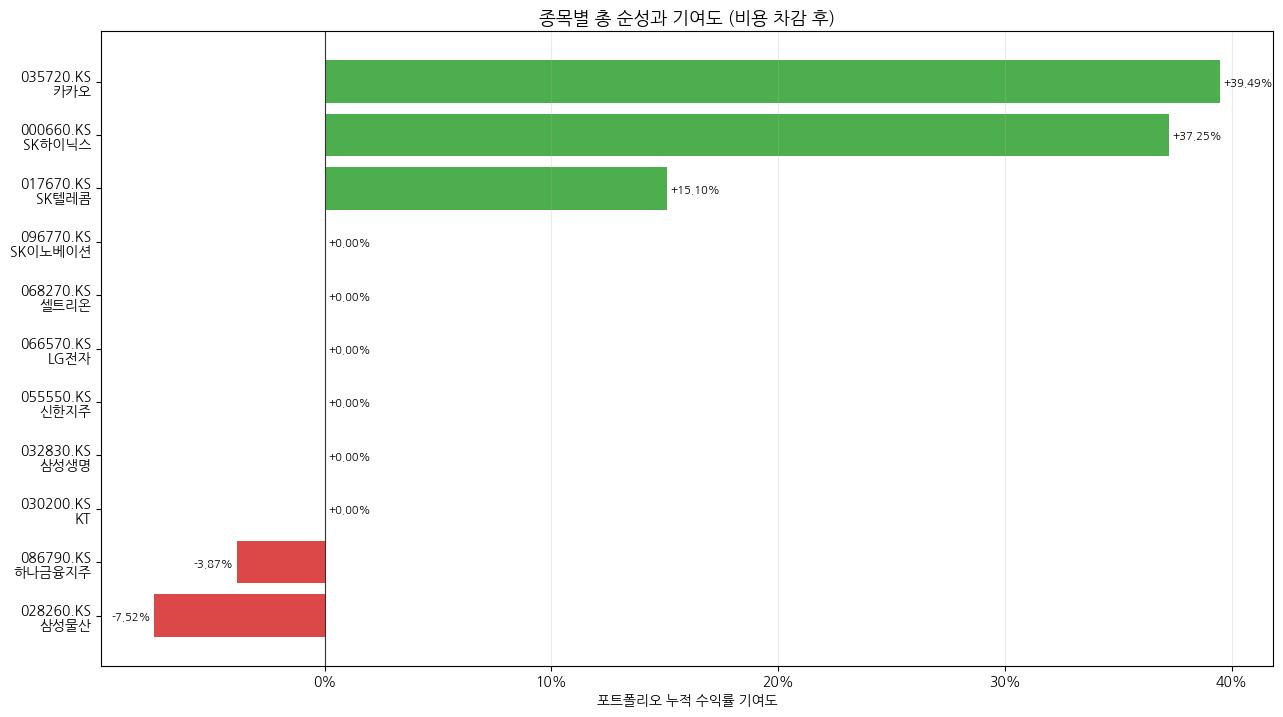

,ticker,gross_contribution,cost_ratio,net_contribution,gross_amount,cost_amount,net_amount,held_days,avg_weight,max_weight,trade_count,buy_count,sell_count,first_trade,last_trade
0,035720.KS,+40.94%,+1.46%,+39.49%,"5,829,829원","187,055원","5,642,774원",720,30.2%,70.0%,105,38,67,2010-06-25,2017-12-13
1,000660.KS,+39.17%,+1.92%,+37.25%,"5,037,171원","257,273원","4,779,899원",1037,29.7%,70.0%,144,57,87,2010-07-12,2017-12-08
2,017670.KS,+17.08%,+1.97%,+15.10%,"1,698,319원","247,626원","1,450,694원",1121,24.3%,70.0%,148,46,102,2010-10-07,2017-11-29
3,030200.KS,+0.00%,+0.00%,+0.00%,0원,0원,0원,0,0.0%,0.0%,0,0,0,,
4,032830.KS,+0.00%,+0.00%,+0.00%,0원,0원,0원,0,0.0%,0.0%,0,0,0,,
5,055550.KS,+0.00%,+0.00%,+0.00%,0원,0원,0원,0,0.0%,0.0%,0,0,0,,
6,066570.KS,+0.00%,+0.00%,+0.00%,0원,0원,0원,0,0.0%,0.0%,0,0,0,,
7,068270.KS,+0.00%,+0.00%,+0.00%,0원,0원,0원,0,0.0%,0.0%,0,0,0,,
8,096770.KS,+0.00%,+0.00%,+0.00%,0원,0원,0원,0,0.0%,0.0%,0,0,0,,
9,086790.KS,-2.11%,+1.76%,-3.87%,"-238,458원","212,571원","-451,029원",779,24.8%,70.0%,109,41,68,2010-08-25,2017-09-05


종목별 성과 해석
- 성과 기여 상위 종목: 035720.KS(+39.49%), 000660.KS(+37.25%), 017670.KS(+15.10%)
- 성과 기여 하위 종목: 028260.KS(-7.52%), 086790.KS(-3.87%), 030200.KS(+0.00%)
- 거래 비용 부담이 가장 큰 종목은 000660.KS이며 비용은 약 257,273원입니다.


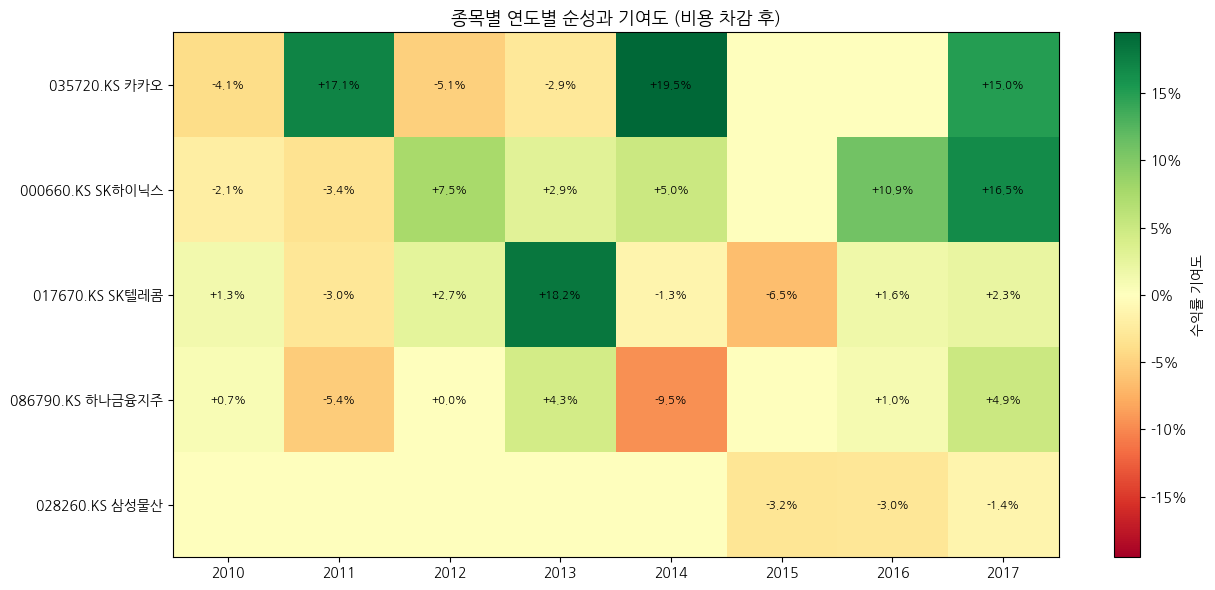

,year,ticker,gross_contribution,cost_ratio,net_contribution,gross_amount,cost_amount,net_amount,held_days,avg_weight,max_weight,trade_count,buy_count,sell_count
0,2010,017670.KS,+1.37%,+0.11%,+1.26%,"126,284원","10,065원","116,219원",36,14.9%,40.0%,5,3,2
1,2010,086790.KS,+1.10%,+0.38%,+0.71%,"66,223원","35,111원","31,112원",45,45.6%,70.0%,12,5,7
2,2010,000660.KS,-2.00%,+0.06%,-2.06%,"-193,955원","5,583원","-199,538원",32,19.0%,37.5%,7,4,3
3,2010,035720.KS,-3.89%,+0.21%,-4.09%,"-390,615원","20,418원","-411,034원",27,51.0%,70.0%,5,3,2
4,2011,035720.KS,+17.52%,+0.45%,+17.07%,"1,722,732원","48,195원","1,674,536원",237,34.9%,70.0%,23,10,13
5,2011,017670.KS,-2.88%,+0.16%,-3.04%,"-308,990원","17,413원","-326,403원",102,15.7%,40.0%,16,2,14
6,2011,000660.KS,-3.15%,+0.27%,-3.42%,"-436,735원","27,133원","-463,868원",166,26.3%,53.2%,16,7,9
7,2011,086790.KS,-5.11%,+0.27%,-5.38%,"-591,726원","27,127원","-618,853원",107,20.1%,45.5%,17,4,13
8,2012,000660.KS,+7.71%,+0.24%,+7.47%,"690,723원","24,867원","665,856원",110,48.4%,70.0%,13,5,8
9,2012,017670.KS,+2.83%,+0.17%,+2.66%,"264,231원","17,194원","247,037원",130,34.4%,70.0%,12,5,7


In [13]:
ticker_perf = summarize_ticker_performance(result)
ticker_yearly_perf = summarize_ticker_yearly_performance(result)

fig = plot_ticker_contribution_bar(result, get_ticker_name=get_ticker_name)
plt.show()

if not ticker_perf.empty:
    ticker_perf_view = format_analysis_table(
        ticker_perf,
        pct_cols=['gross_contribution', 'cost_ratio', 'net_contribution'],
        amount_cols=['gross_amount', 'cost_amount', 'net_amount'],
        weight_cols=['avg_weight', 'max_weight'],
        date_cols=['first_trade', 'last_trade'],
    )
    display(ticker_perf_view)

print('종목별 성과 해석')
for message in interpret_ticker_performance(ticker_perf):
    print(f'- {message}')

fig = plot_ticker_yearly_contribution_heatmap(result, get_ticker_name=get_ticker_name)
plt.show()

if not ticker_yearly_perf.empty:
    ticker_yearly_view = format_analysis_table(
        ticker_yearly_perf,
        pct_cols=['gross_contribution', 'cost_ratio', 'net_contribution'],
        amount_cols=['gross_amount', 'cost_amount', 'net_amount'],
        weight_cols=['avg_weight', 'max_weight'],
    )
    display(ticker_yearly_view)

### 5-3. 연도별/총 거래 건수 및 거래 비용

거래 횟수와 회전율, 거래 비용을 연도별로 확인한다.  
총 비용은 백테스트 성과 지표 계산에서 이미 차감된 비용이며, 매수에는 수수료+슬리피지, 매도에는 수수료+슬리피지+거래세가 반영된다.


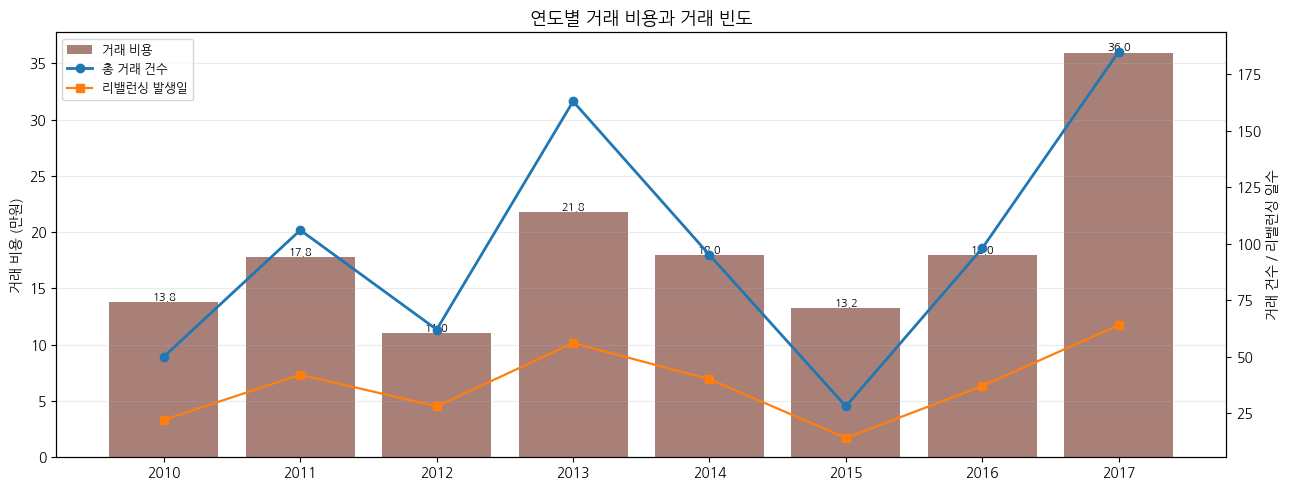

,year,trade_count,buy_count,sell_count,traded_assets,rebalance_days,total_turnover,total_cost_ratio,total_cost_amount
0,2010,50,22,28,5,22,11.78x,+1.47%,"138,162원"
1,2011,106,36,70,5,42,13.52x,+1.69%,"178,117원"
2,2012,62,23,39,5,28,8.72x,+1.09%,"110,419원"
3,2013,163,59,104,5,56,15.33x,+1.92%,"217,544원"
4,2014,95,40,55,5,40,10.82x,+1.35%,"179,766원"
5,2015,28,14,14,3,14,7.60x,+0.95%,"132,444원"
6,2016,98,32,66,5,37,10.94x,+1.37%,"179,554원"
7,2017,185,52,133,6,64,15.39x,+1.92%,"359,579원"
8,TOTAL,787,278,509,6,303,94.10x,+11.76%,"1,495,585원"


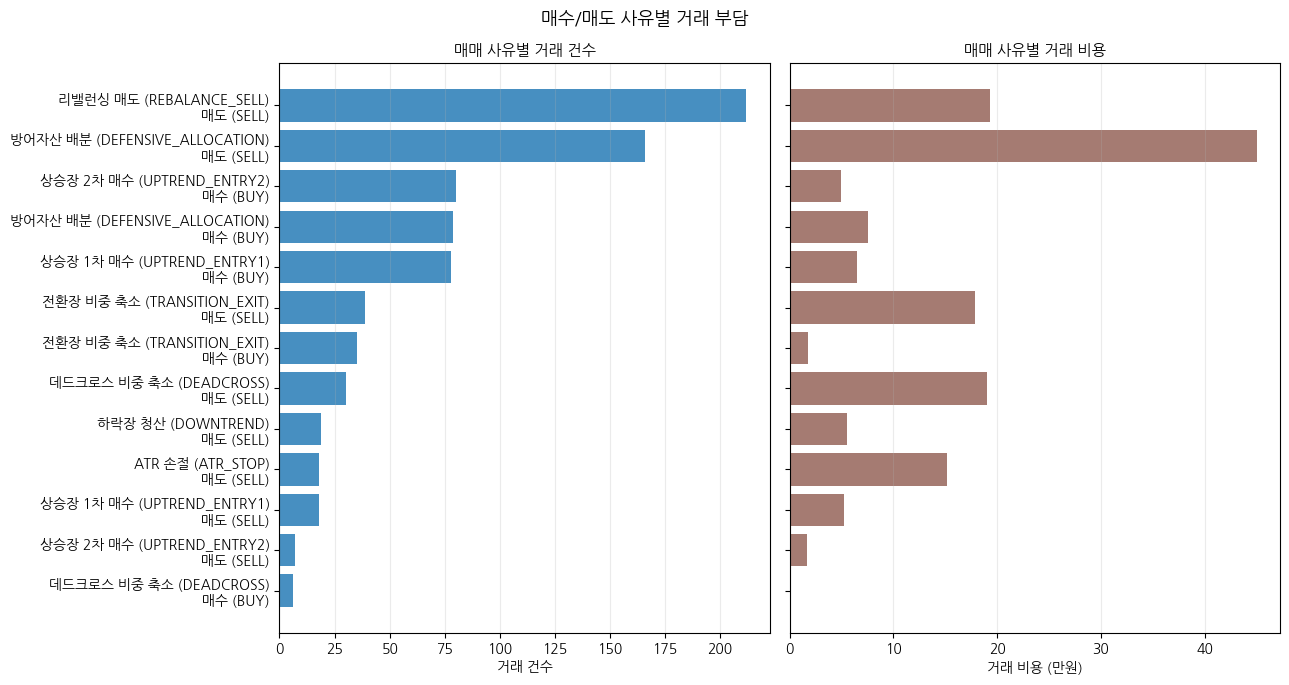

,reason_name,trade_reason,side_name,side,trade_count,total_turnover,total_cost_ratio,total_cost_amount
0,리밸런싱 매도,REBALANCE_SELL,매도,SELL,212,6.67x,+1.43%,"193,192원"
1,방어자산 배분,DEFENSIVE_ALLOCATION,매도,SELL,166,16.88x,+3.63%,"449,859원"
2,상승장 2차 매수,UPTREND_ENTRY2,매수,BUY,80,11.48x,+0.40%,"49,868원"
3,방어자산 배분,DEFENSIVE_ALLOCATION,매수,BUY,79,16.68x,+0.58%,"75,589원"
4,상승장 1차 매수,UPTREND_ENTRY1,매수,BUY,78,14.79x,+0.52%,"64,583원"
5,전환장 비중 축소,TRANSITION_EXIT,매도,SELL,39,6.76x,+1.45%,"178,199원"
6,전환장 비중 축소,TRANSITION_EXIT,매수,BUY,35,3.84x,+0.13%,"18,124원"
7,데드크로스 비중 축소,DEADCROSS,매도,SELL,30,7.03x,+1.51%,"190,503원"
8,하락장 청산,DOWNTREND,매도,SELL,19,1.89x,+0.41%,"54,834원"
9,ATR 손절,ATR_STOP,매도,SELL,18,5.17x,+1.11%,"151,230원"


거래 비용 해석
- 전체 거래는 787건, 총 거래 비용은 약 1,495,585원입니다.
- 거래 비용이 가장 컸던 해는 2017년입니다.
- 가장 자주 발생한 매매 사유는 REBALANCE_SELL / SELL입니다.


In [14]:
trade_cost_by_year = summarize_trade_costs_by_year(result)
trade_reason_summary = summarize_trade_reasons(result)

fig = plot_trade_costs_by_year(result)
plt.show()

if not trade_cost_by_year.empty:
    trade_cost_view = format_analysis_table(
        trade_cost_by_year,
        pct_cols=['total_cost_ratio'],
        amount_cols=['total_cost_amount'],
        turnover_cols=['total_turnover'],
    )
    display(trade_cost_view)

fig = plot_trade_reason_burden(result)
plt.show()

if not trade_reason_summary.empty:
    reason_view = add_trade_reason_labels(trade_reason_summary)
    reason_view = format_analysis_table(
        reason_view,
        pct_cols=['total_cost_ratio'],
        amount_cols=['total_cost_amount'],
        turnover_cols=['total_turnover'],
    )
    display(
        reason_view[
            [
                'reason_name',
                'trade_reason',
                'side_name',
                'side',
                'trade_count',
                'total_turnover',
                'total_cost_ratio',
                'total_cost_amount',
            ]
        ]
    )

print('거래 비용 해석')
for message in interpret_trade_costs(trade_cost_by_year, trade_reason_summary):
    print(f'- {message}')

---
## 6. 비교 자산 성과 계산

전략 성과를 **단기채 100%** 및 **KOSPI B&H(Buy-and-Hold)** 와 비교한다.

In [15]:
# 백테스트 기간 캘린더에 맞게 정렬
bt_idx = result.equity_curve.index

# 단기채 100% 누적 자산 곡선
bond_ret_bt = bond_returns.reindex(bt_idx).fillna(0)
bond_equity_bt = (1 + bond_ret_bt).cumprod() * INITIAL_CAPITAL

# KOSPI B&H 누적 자산 곡선
kospi_ret_bt = kospi_index.reindex(bt_idx, method='ffill').pct_change().fillna(0)
kospi_equity_bt = (1 + kospi_ret_bt).cumprod() * INITIAL_CAPITAL

compare_summary = summarize_compare_assets(
    {
        '위험중립형': result.equity_curve,
        '단기채 100%': bond_equity_bt,
        'KOSPI': kospi_equity_bt,
    },
    risk_free_rate=RISK_FREE_RATE,
)
compare_summary_df = build_compare_assets_table(compare_summary)
compare_summary_df.index.name = '지표'

# 아래 시각화 셀에서 기존 변수명을 계속 사용할 수 있도록 유지한다.
stats_by_asset = compare_summary.set_index('asset').to_dict('index')
stats_strategy = dict(stats_by_asset['위험중립형'])
stats_bond = dict(stats_by_asset['단기채 100%'])
stats_kospi = dict(stats_by_asset['KOSPI'])
for stats in (stats_strategy, stats_bond, stats_kospi):
    stats['final_val'] = stats['final_value']
    stats['total_ret'] = stats['total_return']
    stats['vol'] = stats['volatility']

print('비교 성과 요약')
display(compare_summary_df)

print('비교 자산 해석')
for message in interpret_compare_assets(compare_summary):
    print(f'- {message}')

비교 성과 요약


,위험중립형,단기채 100%,KOSPI
지표,,,
최종 자산(만원),"2,037.5","1,127.4","1,454.8"
총 수익률,+103.75%,+12.74%,+45.48%
CAGR,+9.51%,+1.54%,+4.90%
MDD,-22.39%,-0.52%,-25.85%
MDD 기간(개월),28.8,2.3,70.7
Calmar,0.425,2.968,0.189
Sharpe,0.454,-4.863,0.194
Sortino,0.589,-2.029,0.255
연간 변동성,16.32%,0.30%,15.10%


비교 자산 해석
- 총 수익률이 가장 높은 자산은 위험중립형(+103.75%)입니다.
- MDD가 가장 낮은 자산은 단기채 100%(-0.52%)입니다.


---
## 7. 투자 결과 시각화
### 7-1. 종합 자산 곡선 비교 (전략 vs 단기채 100% vs KOSPI)

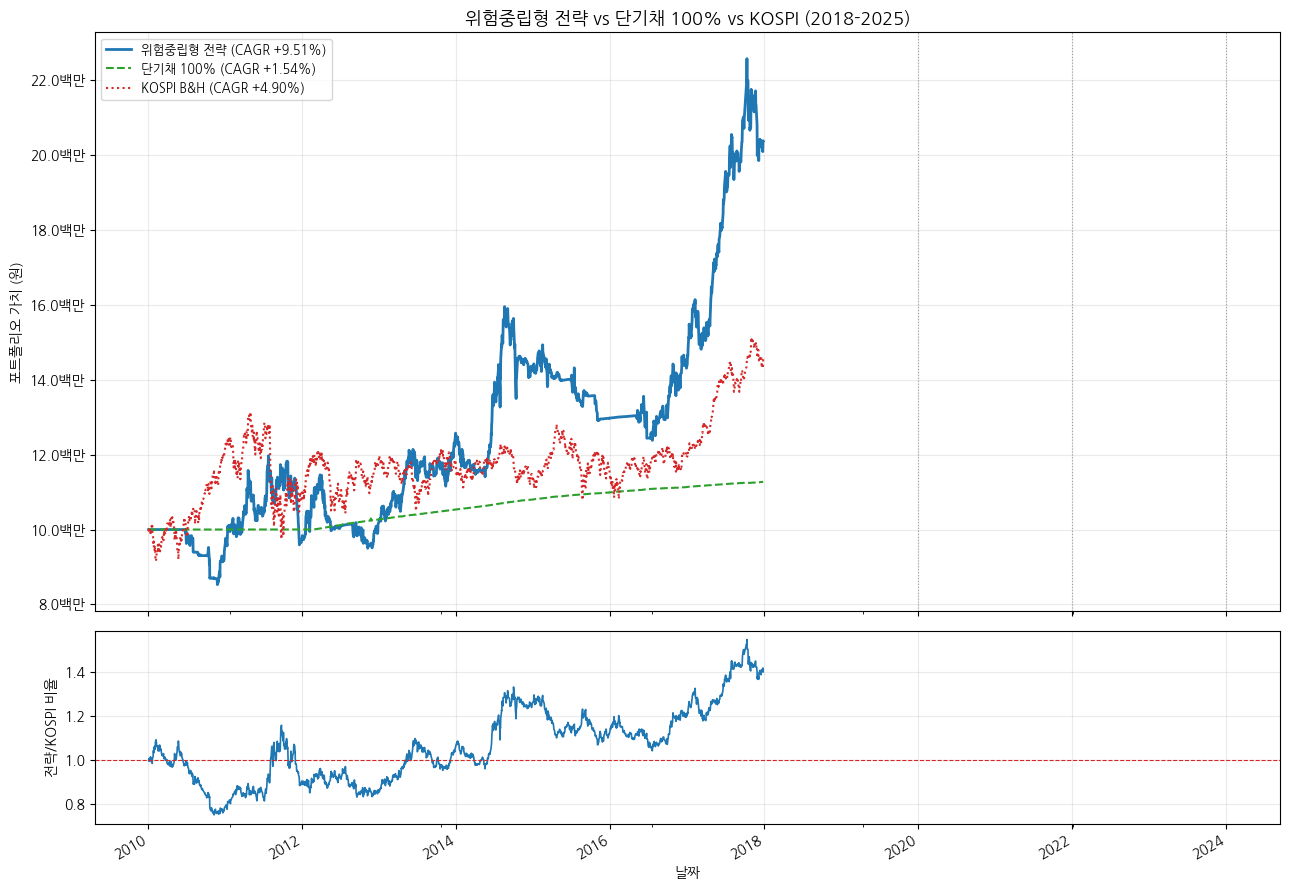

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9),
                         gridspec_kw={'height_ratios': [3, 1]},
                         sharex=True)
ax_equity, ax_ratio = axes

# ── 자산 곡선 ─────────────────────────────────────────────────────────────────
result.equity_curve.plot(
    ax=ax_equity, color='#1f77b4', linewidth=2,
    label=f'위험중립형 전략 (CAGR {stats_strategy["cagr"]:+.2%})'
)
bond_equity_bt.plot(
    ax=ax_equity, color='#2ca02c', linewidth=1.5, linestyle='--',
    label=f'단기채 100% (CAGR {stats_bond["cagr"]:+.2%})'
)
kospi_equity_bt.plot(
    ax=ax_equity, color='#d62728', linewidth=1.5, linestyle=':',
    label=f'KOSPI B&H (CAGR {stats_kospi["cagr"]:+.2%})'
)

# 종목 교체 수직선
for plan in config.rotation_plans:
    ax_equity.axvline(pd.Timestamp(plan.review_date),
                      color='#7f7f7f', linestyle=':', linewidth=0.8, alpha=0.7)

ax_equity.set_title('위험중립형 전략 vs 단기채 100% vs KOSPI (2018-2025)', fontsize=13)
ax_equity.set_ylabel('포트폴리오 가치 (원)')
ax_equity.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}백만'))
ax_equity.legend(loc='upper left', fontsize=9)
ax_equity.grid(True, alpha=0.25)

# ── 전략 / KOSPI 상대 성과 비율 ───────────────────────────────────────────────
ratio = result.equity_curve / kospi_equity_bt
ratio.plot(ax=ax_ratio, color='#1f77b4', linewidth=1.2)
ax_ratio.axhline(1.0, color='#d62728', linewidth=0.8, linestyle='--')
ax_ratio.set_ylabel('전략/KOSPI 비율')
ax_ratio.set_xlabel('날짜')
ax_ratio.grid(True, alpha=0.25)

fig.tight_layout()
plt.show()

### 7-2. 드로우다운 비교 (전략 vs 단기채 100% vs KOSPI)

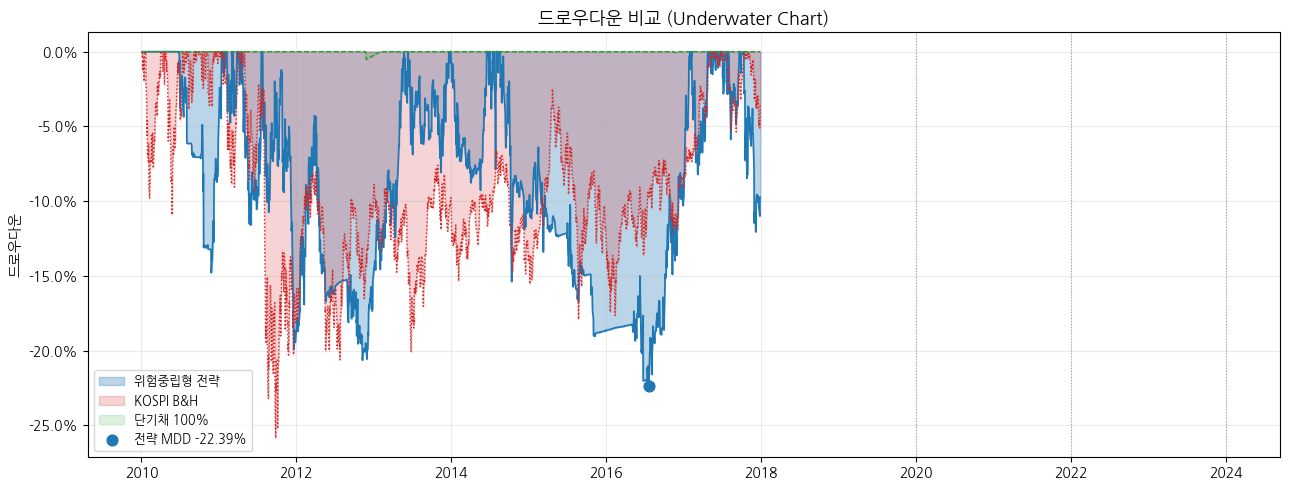

In [17]:
from core.analytics.drawdown import calc_drawdown_series

fig, ax = plt.subplots(figsize=(13, 5))

dd_strategy = calc_drawdown_series(result.equity_curve)
dd_bond     = calc_drawdown_series(bond_equity_bt)
dd_kospi    = calc_drawdown_series(kospi_equity_bt)

ax.fill_between(dd_strategy.index, dd_strategy.values, 0,
                color='#1f77b4', alpha=0.30, label='위험중립형 전략')
ax.plot(dd_strategy.index, dd_strategy.values, color='#1f77b4', linewidth=1.2)

ax.fill_between(dd_kospi.index, dd_kospi.values, 0,
                color='#d62728', alpha=0.20, label='KOSPI B&H')
ax.plot(dd_kospi.index, dd_kospi.values, color='#d62728', linewidth=1.0, linestyle=':')

ax.fill_between(dd_bond.index, dd_bond.values, 0,
                color='#2ca02c', alpha=0.15, label='단기채 100%')
ax.plot(dd_bond.index, dd_bond.values, color='#2ca02c', linewidth=1.0, linestyle='--')

# MDD 포인트 표시
mdd_dt = dd_strategy.idxmin()
ax.scatter([mdd_dt], [dd_strategy.loc[mdd_dt]],
           color='#1f77b4', zorder=5, s=60,
           label=f'전략 MDD {dd_strategy.min():.2%}')

# 종목 교체 수직선
for plan in config.rotation_plans:
    ax.axvline(pd.Timestamp(plan.review_date),
               color='#7f7f7f', linestyle=':', linewidth=0.8, alpha=0.7)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('드로우다운 비교 (Underwater Chart)', fontsize=13)
ax.set_ylabel('드로우다운')
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

### 7-3. 월별 수익률 히트맵 (위험중립형 전략)

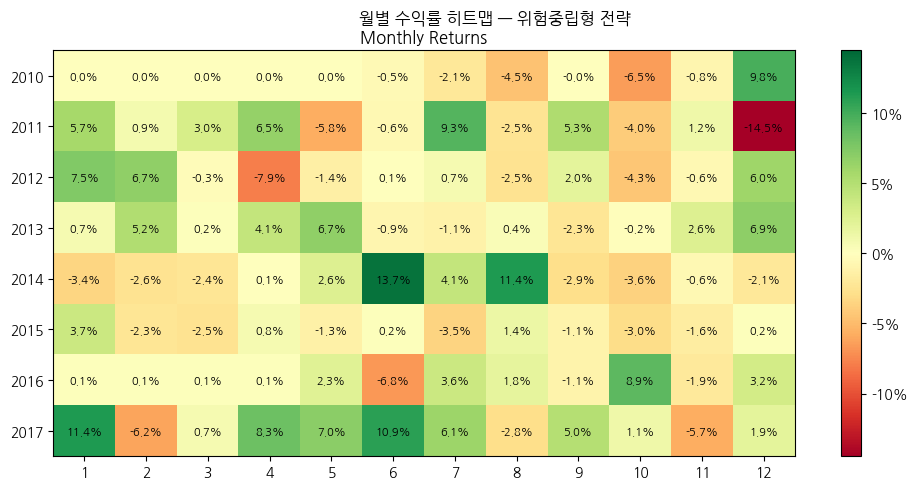

In [18]:
fig = plot_monthly_returns(result)
fig.suptitle('월별 수익률 히트맵 — 위험중립형 전략', fontsize=12, y=1.01)
plt.show()

### 7-4. 연도별 수익률 비교 막대 그래프

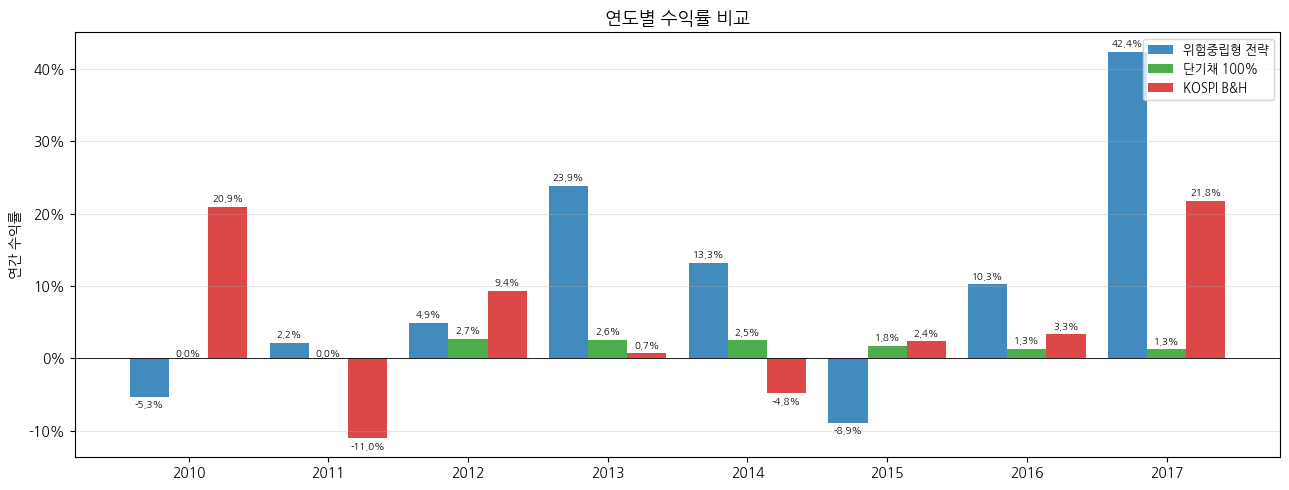

In [19]:
# 연도별 수익률 계산
def annual_returns(equity: pd.Series) -> pd.Series:
    return (1 + equity.pct_change().fillna(0)).resample('Y').prod() - 1

ar_strat = annual_returns(result.equity_curve)
ar_bond  = annual_returns(bond_equity_bt)
ar_kospi = annual_returns(kospi_equity_bt)

years = ar_strat.index.year
x     = np.arange(len(years))
width = 0.28

fig, ax = plt.subplots(figsize=(13, 5))

bars1 = ax.bar(x - width,     ar_strat.values, width, label='위험중립형 전략', color='#1f77b4', alpha=0.85)
bars2 = ax.bar(x,             ar_bond.values,  width, label='단기채 100%',    color='#2ca02c', alpha=0.85)
bars3 = ax.bar(x + width,     ar_kospi.values, width, label='KOSPI B&H',     color='#d62728', alpha=0.85)

ax.axhline(0, color='black', linewidth=0.6)

# 값 레이블
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005 * np.sign(h),
                f'{h:.1%}', ha='center', va='bottom' if h >= 0 else 'top', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([str(y) for y in years])
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('연도별 수익률 비교', fontsize=13)
ax.set_ylabel('연간 수익률')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

---
## 8. 시장 국면 분석
### 8-1. KOSPI 기준 국면과 포트폴리오 자산 곡선

배경 색상은 **KOSPI 종가 기반 국면**이다. KOSPI 데이터는 종가만 사용하므로, 아래 국면은 전략 내부의 종목별 ADX 국면과 달리 **MA20/MA60/MA120 배열 + 60일 박스권**으로 근사한다.  
파란선은 위험중립형 전략의 실제 포트폴리오 자산 곡선이며, 아래 패널은 KOSPI를 초기 투자금 기준으로 환산한 비교 곡선이다.


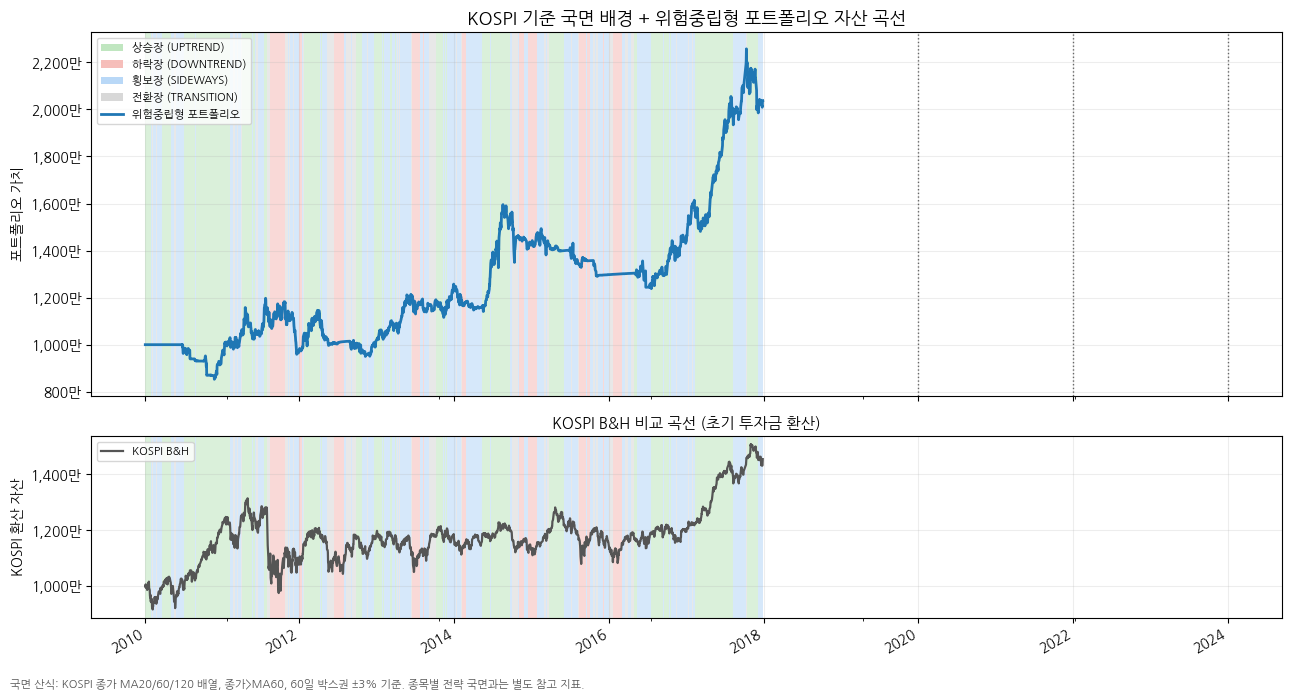

In [20]:
fig = plot_kospi_regime_portfolio(
    result,
    kospi_index,
    initial_capital=INITIAL_CAPITAL,
)
fig.text(
    0.01,
    0.01,
    '국면 산식: KOSPI 종가 MA20/60/120 배열, 종가>MA60, 60일 박스권 ±3% 기준. 종목별 전략 국면과는 별도 참고 지표.',
    fontsize=8,
    color='#555555',
)
fig.tight_layout(rect=(0, 0.035, 1, 1))
plt.show()

### 8-2. 종목별 국면 분포 (보유 기간 기준)

종목별 국면은 각 종목 OHLCV와 KOSPI 필터로 따로 계산된다.  
아래 표는 실제 보유 중이던 날짜만 기준으로 어떤 국면에 노출됐는지 보여준다.


종목별 보유 기간 기준 국면 노출
------------------------------------------------------------


regime,SIDEWAYS,TRANSITION,UPTREND
ticker,,,
000660.KS,0.0%,54.4%,45.6%
017670.KS,0.0%,53.7%,46.3%
028260.KS,0.0%,67.8%,32.2%
035720.KS,0.0%,50.4%,49.6%
086790.KS,0.1%,57.4%,42.5%


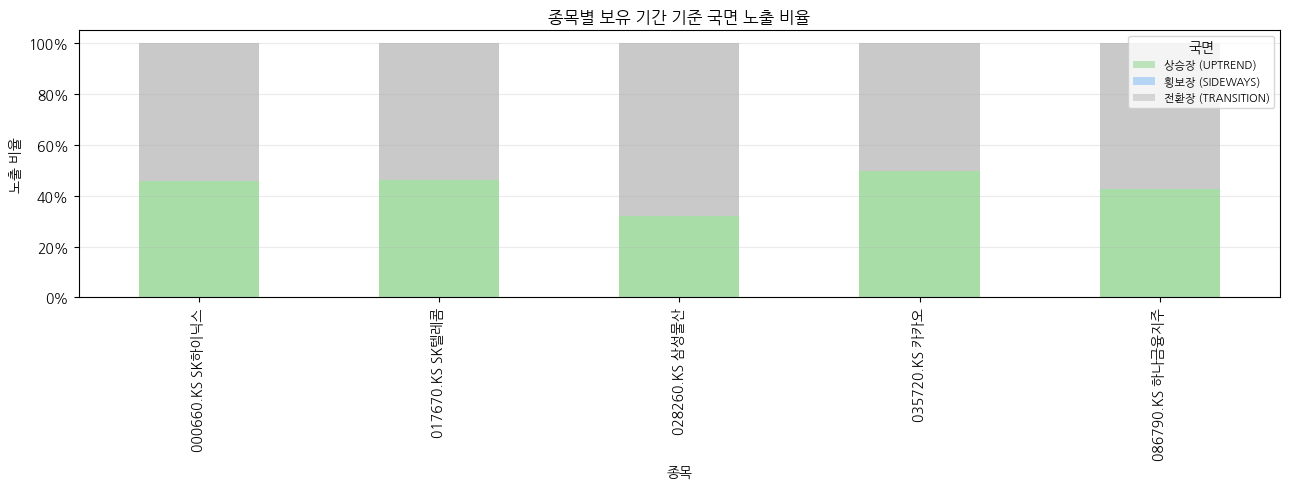

국면 노출 해석
- 보유 기간 중 지배적인 국면: 000660.KS=TRANSITION(54.4%), 017670.KS=TRANSITION(53.7%), 028260.KS=TRANSITION(67.8%), 035720.KS=TRANSITION(50.4%), 086790.KS=TRANSITION(57.4%)


In [21]:
regime_exposure_held = summarize_regime_exposure_by_ticker(result, held_only=True)
regime_exposure_all = summarize_regime_exposure_by_ticker(result, held_only=False)

print('종목별 보유 기간 기준 국면 노출')
print('-' * 60)
if regime_exposure_held.empty:
    print('보유 기간 기준 국면 노출이 없습니다.')
else:
    regime_pivot = (
        regime_exposure_held
        .pivot(index='ticker', columns='regime', values='ratio')
        .fillna(0.0)
    )
    display(regime_pivot.applymap(lambda v: f'{v:.1%}'))

fig = plot_regime_exposure_by_ticker(result, get_ticker_name=get_ticker_name, held_only=True)
plt.show()

print('국면 노출 해석')
for message in interpret_regime_exposure(regime_exposure_held):
    print(f'- {message}')

### 8-3. 종목별 국면과 해당 종목 투자금 곡선

각 패널의 배경은 **해당 종목 자체 국면**이고, 파란선은 전략이 그 종목에 실제로 배정한 투자금이다.  
따라서 이 선은 종목 가격이 아니라 `포트폴리오 가치 × 해당 종목 비중`으로 계산된 보유 평가금액이다.


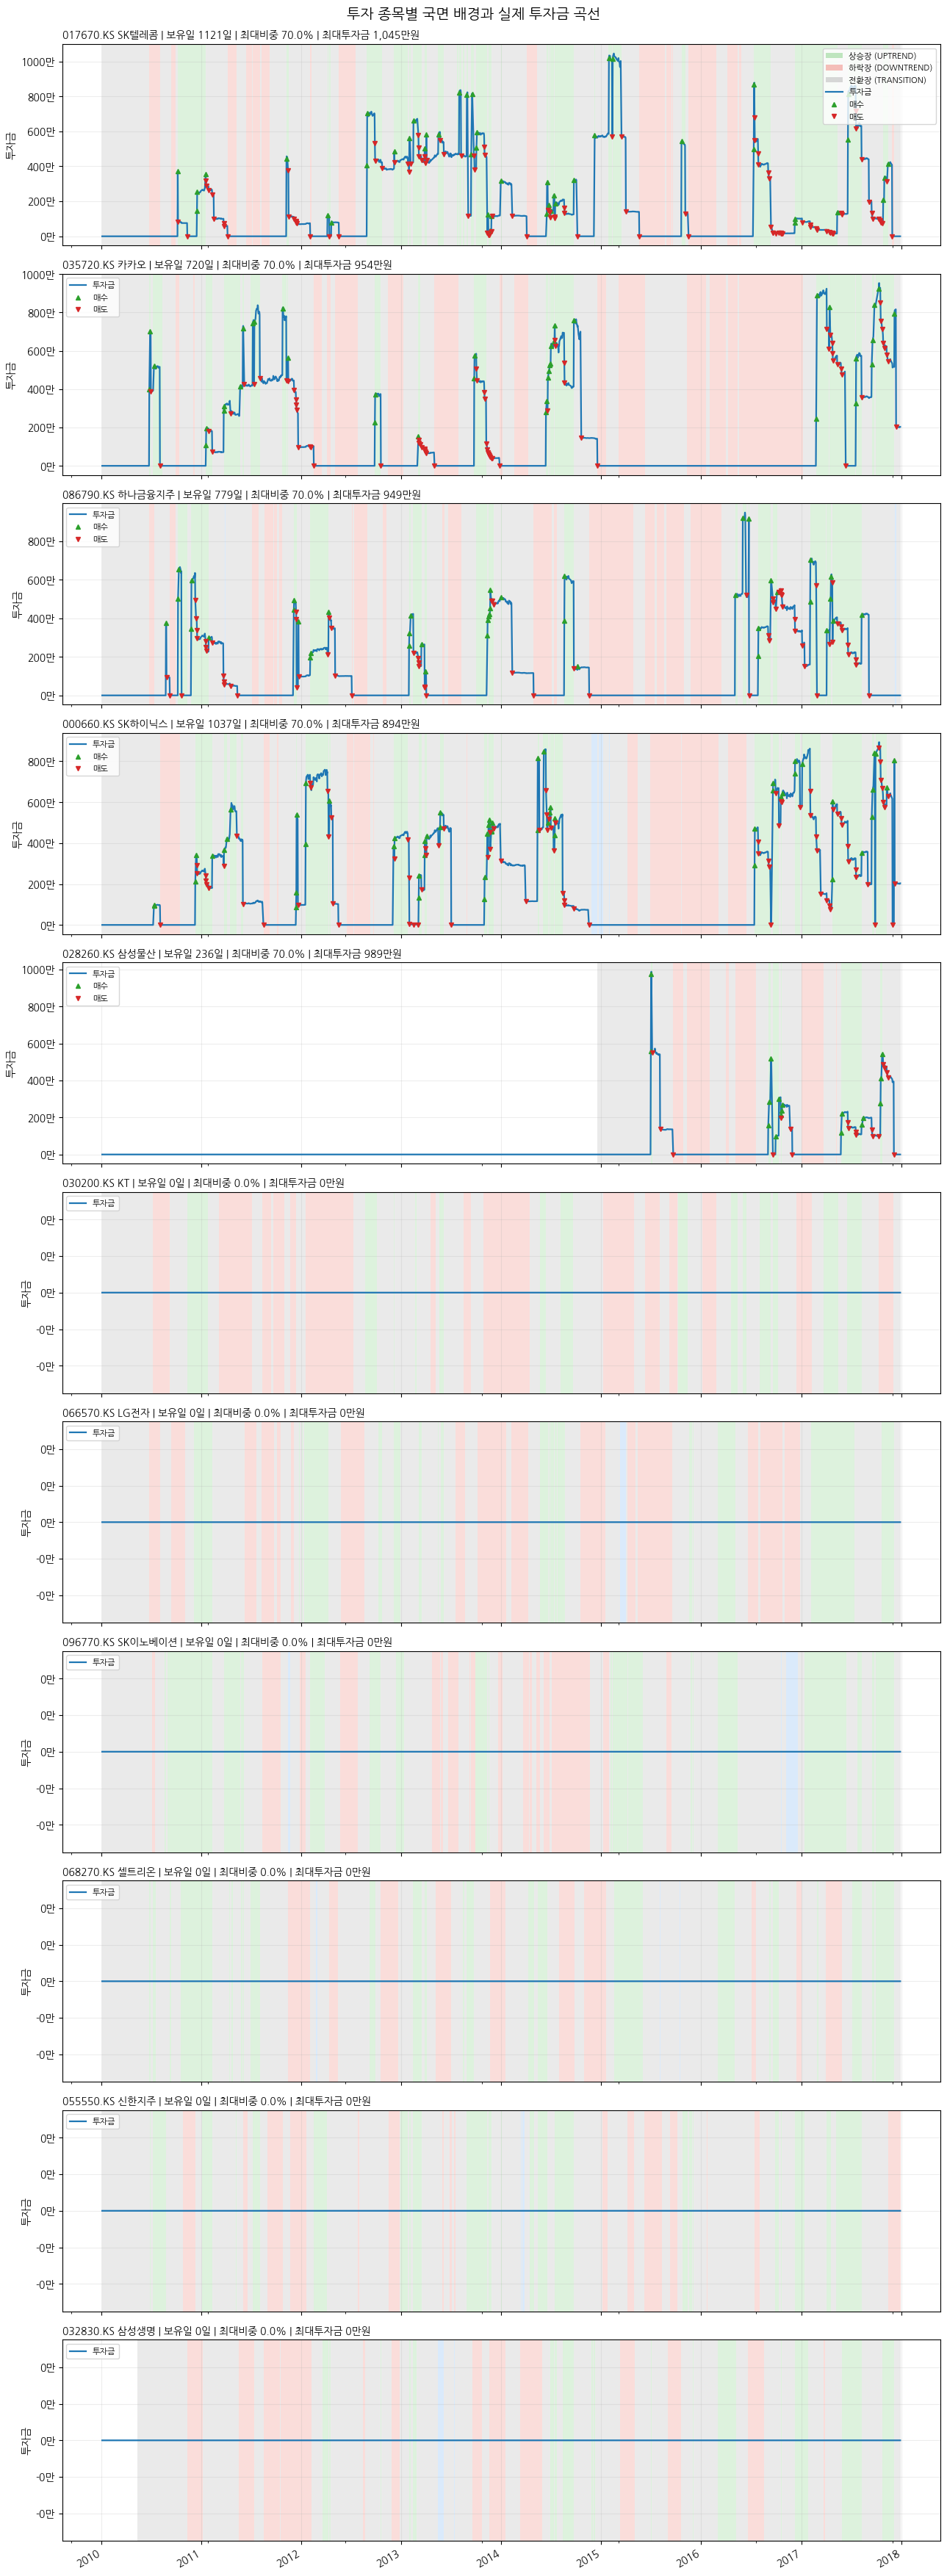

In [22]:
fig = plot_ticker_regime_invested_values(result, get_ticker_name=get_ticker_name)
plt.show()

In [23]:
# 국면별 통계
if result.regime_dict:
    first_ticker = list(result.regime_dict.keys())[0]
    regime_series = result.regime_dict[first_ticker]['REGIME'].reindex(
        result.equity_curve.index
    ).ffill()

    regime_counts = regime_series.value_counts()
    total = len(regime_series)

    print(f'국면별 거래일 통계 ({first_ticker} 기준)')
    print('-' * 40)
    for regime, count in regime_counts.items():
        emoji = {'UPTREND': '📈', 'DOWNTREND': '📉', 'SIDEWAYS': '↔️', 'TRANSITION': '🔄'}.get(regime, '')
        print(f'  {emoji} {regime:<12}: {count:>5}일  ({count/total:.1%})')

국면별 거래일 통계 (017670.KS 기준)
----------------------------------------
  🔄 TRANSITION  :  1073일  (54.3%)
  📈 UPTREND     :   544일  (27.5%)
  📉 DOWNTREND   :   358일  (18.1%)


### 8-4. Walk-Forward 최적화 윈도우

In [24]:
# WF 요약
print('Walk-Forward 요약')
print('-' * 60)
for ticker, windows in result.wf_windows.items():
    if not windows:
        continue
    name = get_ticker_name(ticker)
    print(f'  [{ticker}  {name}]  WF 구간 수: {len(windows)}')
    for w in windows[:3]:  # 처음 3개만
        params = w.get('best_params') or {}
        print(f'    IS {w["is_start"].date()}~{w["is_end"].date()} '
              f'OOS {w["oos_start"].date()}~{w["oos_end"].date()} '
              f'Score={w.get("is_score",0):.2f} Params={params}')

Walk-Forward 요약
------------------------------------------------------------
  [017670.KS  SK텔레콤]  WF 구간 수: 28
    IS 2010-01-04~2011-01-03 OOS 2011-01-04~2011-04-01 Score=4.35 Params={'adx_threshold': 25.0, 'adx_sideways': 10.0}
    IS 2010-04-05~2011-04-01 OOS 2011-04-04~2011-07-01 Score=-0.24 Params={}
    IS 2010-07-05~2011-07-01 OOS 2011-07-04~2011-09-30 Score=0.18 Params={'adx_threshold': 20.0, 'adx_sideways': 10.0}
  [035720.KS  카카오]  WF 구간 수: 28
    IS 2010-01-04~2011-01-03 OOS 2011-01-04~2011-04-01 Score=0.00 Params={}
    IS 2010-04-05~2011-04-01 OOS 2011-04-04~2011-07-01 Score=2.68 Params={'adx_threshold': 15.0, 'adx_sideways': 10.0}
    IS 2010-07-05~2011-07-01 OOS 2011-07-04~2011-09-30 Score=1.76 Params={'adx_threshold': 15.0, 'adx_sideways': 10.0}
  [086790.KS  하나금융지주]  WF 구간 수: 28
    IS 2010-01-04~2011-01-03 OOS 2011-01-04~2011-04-01 Score=2.73 Params={'adx_threshold': 30.0, 'adx_sideways': 10.0}
    IS 2010-04-05~2011-04-01 OOS 2011-04-04~2011-07-01 Score=1.62 Params={

### 8-5. 유니버스 교체 타임라인

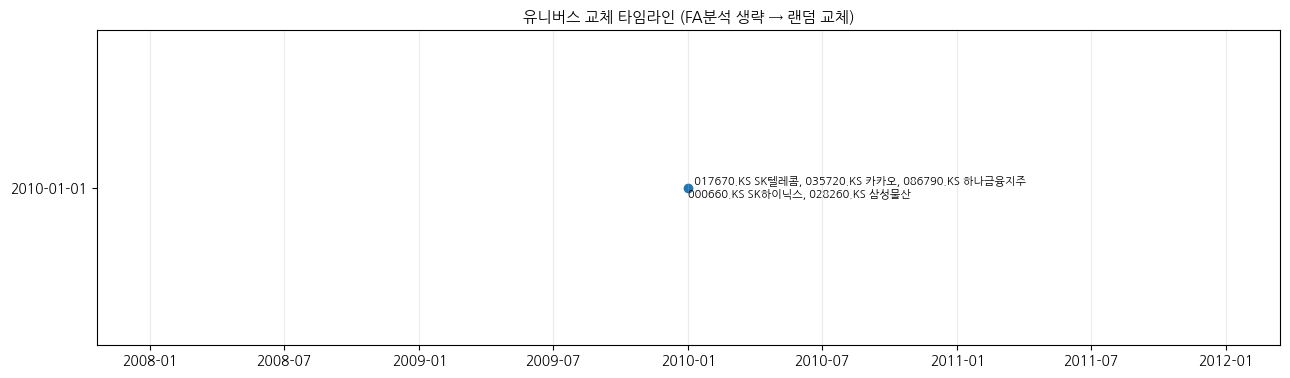

유니버스 스냅샷
--------------------------------------------------
  2010-01-01: 017670.KS(SK텔레콤), 035720.KS(카카오), 086790.KS(하나금융지주), 000660.KS(SK하이닉스), 028260.KS(삼성물산)


In [25]:
fig = plot_universe_timeline(result, get_ticker_name=get_ticker_name)
fig.set_size_inches(13, max(4, 0.6 * len(result.universe_snapshots) + 2))
fig.axes[0].set_title('유니버스 교체 타임라인 (FA분석 생략 → 랜덤 교체)', fontsize=11)
plt.show()

print('유니버스 스냅샷')
print('-' * 50)
for dt, tickers_snap in result.universe_snapshots:
    names = [f'{t}({get_ticker_name(t)})' for t in tickers_snap]
    # Python 3.10 호환: f-string 안 join 표현식 분리
    names_str = ', '.join(names) if names else '(비어있음)'
    print(f'  {str(dt)}: {names_str}')

---
## 9. 포트폴리오 비중 분석

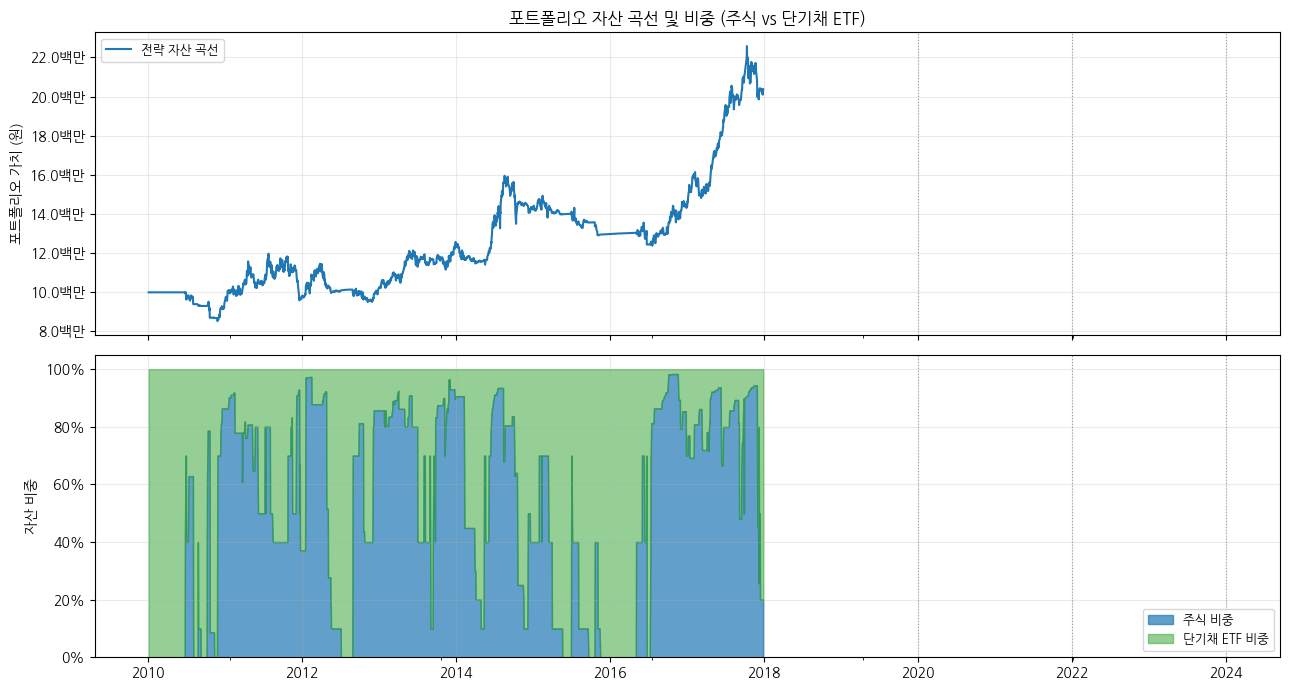

평균 주식 비중  : 52.1%
평균 단기채 비중: 47.9%
주식 비중 0% 일수: 373일 (18.9%)


In [26]:
weights = result.weights

# 주식 비중 vs 방어자산 비중 분리
stock_cols = [c for c in weights.columns if c not in ('BOND_ETF', 'INVERSE_ETF')]
bond_cols  = [c for c in weights.columns if c in ('BOND_ETF', 'INVERSE_ETF')]

stock_weight = weights[stock_cols].sum(axis=1)
bond_weight  = weights[bond_cols].sum(axis=1) if bond_cols else pd.Series(0, index=weights.index)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# 자산 곡선
result.equity_curve.plot(ax=axes[0], color='#1f77b4', linewidth=1.5, label='전략 자산 곡선')
axes[0].set_ylabel('포트폴리오 가치 (원)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}백만'))
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.25)

# 비중 스택 차트
axes[1].fill_between(weights.index, stock_weight, label='주식 비중', color='#1f77b4', alpha=0.7)
axes[1].fill_between(weights.index, 1.0, stock_weight, label='단기채 ETF 비중', color='#2ca02c', alpha=0.5)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('자산 비중')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(True, alpha=0.25)

# 종목 교체 수직선
for plan in config.rotation_plans:
    for ax in axes:
        ax.axvline(pd.Timestamp(plan.review_date),
                   color='#7f7f7f', linestyle=':', linewidth=0.8, alpha=0.7)

axes[0].set_title('포트폴리오 자산 곡선 및 비중 (주식 vs 단기채 ETF)', fontsize=12)
fig.tight_layout()
plt.show()

# 통계
print(f'평균 주식 비중  : {stock_weight.mean():.1%}')
print(f'평균 단기채 비중: {bond_weight.mean():.1%}')
print(f'주식 비중 0% 일수: {(stock_weight < 0.01).sum()}일 ({(stock_weight < 0.01).mean():.1%})')

---
## 10. 종목별 상세 분석

투자 종목별로 실제 목표 비중이 바뀐 날짜와 매수/매도 사유를 확인한다.  
`trade_reason`은 전략 신호, 강제 청산, 방어자산 배분 등 최종 거래가 발생한 이유를 나타낸다.


In [27]:
trade_ledger = result.trade_ledger.copy() if result.trade_ledger is not None else pd.DataFrame()
stock_trade_ledger = trade_ledger[trade_ledger['ticker'].isin(result.signals.columns)].copy() if not trade_ledger.empty else pd.DataFrame()

print('종목별 매수/매도 상세 로그')
print('-' * 60)
if stock_trade_ledger.empty:
    print('표시할 주식 거래 로그가 없습니다.')
else:
    stock_trade_ledger['name'] = stock_trade_ledger['ticker'].map(get_ticker_name)
    detail_cols = [
        'date', 'ticker', 'name', 'side', 'trade_reason',
        'prev_weight', 'target_weight', 'delta_weight', 'trade_turnover',
        'cost_amount', 'regime', 'price', 'exit_reason', 'secondary_exit_reason',
    ]
    detail_view = stock_trade_ledger[detail_cols].sort_values(['date', 'ticker']).copy()
    detail_view['date'] = pd.to_datetime(detail_view['date']).dt.strftime('%Y-%m-%d')
    for col in ['prev_weight', 'target_weight', 'delta_weight', 'trade_turnover']:
        detail_view[col] = detail_view[col].map(lambda v: f'{float(v):+.1%}' if col == 'delta_weight' else f'{float(v):.1%}')
    detail_view['cost_amount'] = detail_view['cost_amount'].map(lambda v: f'{float(v):,.0f}원')
    detail_view['price'] = detail_view['price'].map(lambda v: '' if pd.isna(v) else f'{float(v):,.0f}')
    display(detail_view)

print('종목별 매수/매도 사유 집계')
print('-' * 60)
if stock_trade_ledger.empty:
    print('표시할 주식 거래 사유 집계가 없습니다.')
else:
    reason_by_ticker = (
        stock_trade_ledger
        .groupby(['ticker', 'trade_reason', 'side'])
        .agg(
            trade_count=('ticker', 'size'),
            total_turnover=('trade_turnover', 'sum'),
            total_cost_amount=('cost_amount', 'sum'),
        )
        .reset_index()
        .sort_values(['ticker', 'trade_count'], ascending=[True, False])
    )
    reason_by_ticker['name'] = reason_by_ticker['ticker'].map(get_ticker_name)
    reason_by_ticker['total_turnover'] = reason_by_ticker['total_turnover'].map(lambda v: f'{float(v):.2f}x')
    reason_by_ticker['total_cost_amount'] = reason_by_ticker['total_cost_amount'].map(lambda v: f'{float(v):,.0f}원')
    display(reason_by_ticker[['ticker', 'name', 'trade_reason', 'side', 'trade_count', 'total_turnover', 'total_cost_amount']])


종목별 매수/매도 상세 로그
------------------------------------------------------------


,date,ticker,name,side,trade_reason,prev_weight,target_weight,delta_weight,trade_turnover,cost_amount,regime,price,exit_reason,secondary_exit_reason
0,2010-06-25,035720.KS,카카오,BUY,UPTREND_ENTRY1,0.0%,40.0%,+40.0%,40.0%,"1,400원",UPTREND,"15,897",None,None
2,2010-06-28,035720.KS,카카오,BUY,UPTREND_ENTRY2,40.0%,70.0%,+30.0%,30.0%,"1,049원",UPTREND,"16,010",None,None
4,2010-07-01,035720.KS,카카오,SELL,TRANSITION_EXIT,70.0%,40.0%,-30.0%,30.0%,"6,420원",TRANSITION,"15,390",TRANSITION_EXIT,None
7,2010-07-12,000660.KS,SK하이닉스,BUY,UPTREND_ENTRY1,0.0%,9.6%,+9.6%,9.6%,331원,UPTREND,"22,039",None,None
6,2010-07-12,035720.KS,카카오,BUY,UPTREND_ENTRY2,40.0%,52.9%,+12.9%,12.9%,443원,UPTREND,"15,860",None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,2017-12-05,028260.KS,삼성물산,SELL,DOWNTREND,19.5%,0.0%,-19.5%,19.5%,"8,491원",DOWNTREND,"114,324",DOWNTREND,None
779,2017-12-06,000660.KS,SK하이닉스,BUY,UPTREND_ENTRY1,0.0%,40.0%,+40.0%,40.0%,"2,831원",UPTREND,"69,228",None,None
781,2017-12-07,035720.KS,카카오,BUY,TRANSITION_EXIT,25.6%,40.0%,+14.4%,14.4%,"1,010원",TRANSITION,"26,850",TRANSITION_EXIT,None
783,2017-12-08,000660.KS,SK하이닉스,SELL,DEADCROSS,40.0%,10.0%,-30.0%,30.0%,"12,805원",TRANSITION,"70,300",DEADCROSS,None


종목별 매수/매도 사유 집계
------------------------------------------------------------


,ticker,name,trade_reason,side,trade_count,total_turnover,total_cost_amount
4,000660.KS,SK하이닉스,REBALANCE_SELL,SELL,51,1.90x,"57,384원"
7,000660.KS,SK하이닉스,UPTREND_ENTRY1,BUY,24,4.20x,"19,754원"
9,000660.KS,SK하이닉스,UPTREND_ENTRY2,BUY,22,2.53x,"10,669원"
6,000660.KS,SK하이닉스,TRANSITION_EXIT,SELL,11,1.19x,"30,679원"
5,000660.KS,SK하이닉스,TRANSITION_EXIT,BUY,10,1.05x,"4,544원"
2,000660.KS,SK하이닉스,DEADCROSS,SELL,9,2.29x,"62,439원"
0,000660.KS,SK하이닉스,ATR_STOP,SELL,6,1.46x,"51,380원"
8,000660.KS,SK하이닉스,UPTREND_ENTRY1,SELL,6,0.56x,"13,514원"
3,000660.KS,SK하이닉스,DOWNTREND,SELL,2,0.20x,"4,407원"
10,000660.KS,SK하이닉스,UPTREND_ENTRY2,SELL,2,0.08x,"2,489원"


---
## 11. KPI 목표 달성 현황 (위험중립형 기준)

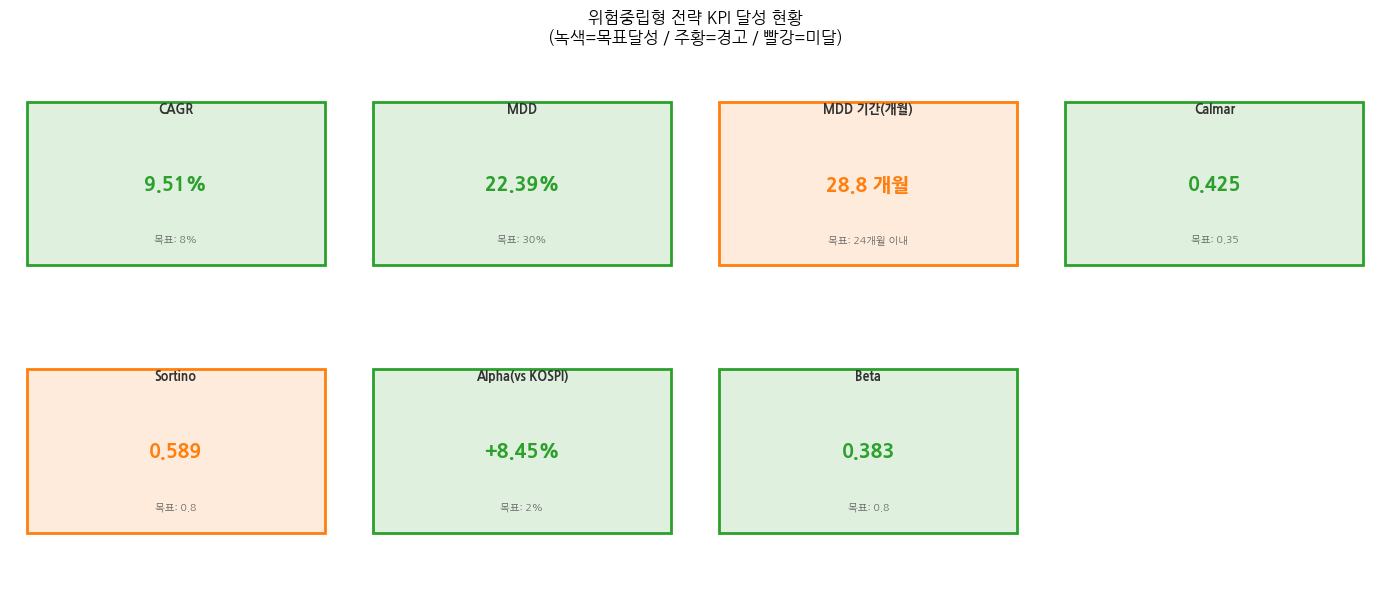

In [28]:
kpi_items = [
    ('CAGR',        perf.cagr,              strategy.TARGET_CAGR,         strategy.WARNING_CAGR,         True,  '%'),
    ('MDD',         abs(perf.mdd),          abs(strategy.TARGET_MDD),     abs(strategy.WARNING_MDD),     False, '%'),
    ('MDD 기간(개월)', perf.mdd_duration_months, strategy.TARGET_MDD_DURATION, strategy.WARNING_MDD_DURATION, False, '개월'),
    ('Calmar',      perf.calmar,            0.35,                          0.20,                          True,  ''),
    ('Sortino',     perf.sortino,           0.80,                          0.50,                          True,  ''),
    ('Alpha(vs KOSPI)', perf.alpha if perf.alpha else 0, 0.02,            0.00,                          True,  '%'),
    ('Beta',        perf.beta if perf.beta else 1,       0.80,            1.00,                          False, ''),
]

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()

for i, (name, value, target, warning, higher_better, unit) in enumerate(kpi_items):
    ax = axes[i]

    if higher_better:
        if value >= target:
            color = '#2ca02c'
        elif value >= warning:
            color = '#ff7f0e'
        else:
            color = '#d62728'
    else:
        if value <= target:
            color = '#2ca02c'
        elif value <= warning:
            color = '#ff7f0e'
        else:
            color = '#d62728'

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    # 배경 색상 박스
    rect = plt.Rectangle((0.05, 0.2), 0.9, 0.65, color=color, alpha=0.15)
    ax.add_patch(rect)
    ax.add_patch(plt.Rectangle((0.05, 0.2), 0.9, 0.65, fill=False, edgecolor=color, linewidth=2))

    # 지표명
    ax.text(0.5, 0.82, name, ha='center', va='center', fontsize=9, fontweight='bold', color='#333333')

    # 값
    if unit == '%':
        val_str = f'{value:+.2%}' if name in ('Alpha(vs KOSPI)',) else f'{value:.2%}'
    elif unit == '개월':
        val_str = f'{value:.1f} 개월'
    else:
        val_str = f'{value:.3f}'
    ax.text(0.5, 0.52, val_str, ha='center', va='center', fontsize=14, fontweight='bold', color=color)

    # 목표값
    if unit == '%':
        tgt_str = f'목표: {target:.0%}'
    elif unit == '개월':
        tgt_str = f'목표: {target:.0f}개월 이내'
    else:
        tgt_str = f'목표: {target}'
    ax.text(0.5, 0.30, tgt_str, ha='center', va='center', fontsize=7.5, color='#666666')

# 마지막 패널 사용 안 함
if len(kpi_items) < len(axes):
    axes[-1].axis('off')

fig.suptitle('위험중립형 전략 KPI 달성 현황\n(녹색=목표달성 / 주황=경고 / 빨강=미달)', fontsize=12)
fig.tight_layout()
plt.show()

---
## 12. 종합 성과 비교 테이블

In [29]:
compare_df = pd.DataFrame({
    '위험중립형 전략': {
        '최종 자산 (만원)': f'{stats_strategy["final_val"]/1e4:,.1f}',
        '총 수익률':        f'{stats_strategy["total_ret"]:+.2%}',
        'CAGR':            f'{stats_strategy["cagr"]:+.2%}',
        'MDD':             f'{stats_strategy["mdd"]:+.2%}',
        'MDD 기간 (개월)': f'{stats_strategy["mdd_months"]:.1f}',
        'Calmar':          f'{stats_strategy["calmar"]:.3f}',
        'Sharpe':          f'{stats_strategy["sharpe"]:.3f}',
        'Sortino':         f'{stats_strategy["sortino"]:.3f}',
        '연간 변동성':     f'{stats_strategy["vol"]:.2%}',
        'Alpha (vs KOSPI)': f'{perf.alpha:+.2%}' if perf.alpha is not None else 'N/A',
        'Beta':            f'{perf.beta:.3f}' if perf.beta is not None else 'N/A',
    },
    '단기채 100%': {
        '최종 자산 (만원)': f'{stats_bond["final_val"]/1e4:,.1f}',
        '총 수익률':        f'{stats_bond["total_ret"]:+.2%}',
        'CAGR':            f'{stats_bond["cagr"]:+.2%}',
        'MDD':             f'{stats_bond["mdd"]:+.2%}',
        'MDD 기간 (개월)': f'{stats_bond["mdd_months"]:.1f}',
        'Calmar':          f'{stats_bond["calmar"]:.3f}',
        'Sharpe':          f'{stats_bond["sharpe"]:.3f}',
        'Sortino':         f'{stats_bond["sortino"]:.3f}',
        '연간 변동성':     f'{stats_bond["vol"]:.2%}',
        'Alpha (vs KOSPI)': '-',
        'Beta':            '-',
    },
    'KOSPI B&H': {
        '최종 자산 (만원)': f'{stats_kospi["final_val"]/1e4:,.1f}',
        '총 수익률':        f'{stats_kospi["total_ret"]:+.2%}',
        'CAGR':            f'{stats_kospi["cagr"]:+.2%}',
        'MDD':             f'{stats_kospi["mdd"]:+.2%}',
        'MDD 기간 (개월)': f'{stats_kospi["mdd_months"]:.1f}',
        'Calmar':          f'{stats_kospi["calmar"]:.3f}',
        'Sharpe':          f'{stats_kospi["sharpe"]:.3f}',
        'Sortino':         f'{stats_kospi["sortino"]:.3f}',
        '연간 변동성':     f'{stats_kospi["vol"]:.2%}',
        'Alpha (vs KOSPI)': '0.00%',
        'Beta':            '1.000',
    },
})

print('\n[종합 성과 비교]')
print(compare_df.to_string())


[종합 성과 비교]
                  위험중립형 전략 단기채 100% KOSPI B&H
최종 자산 (만원)         2,037.5  1,127.4   1,454.8
총 수익률             +103.75%  +12.74%   +45.48%
CAGR                +9.51%   +1.54%    +4.90%
MDD                -22.39%   -0.52%   -25.85%
MDD 기간 (개월)           28.8      2.3      70.7
Calmar               0.425    2.968     0.189
Sharpe               0.454   -4.863     0.194
Sortino              0.589   -2.029     0.255
연간 변동성              16.32%    0.30%    15.10%
Alpha (vs KOSPI)    +8.45%        -     0.00%
Beta                 0.383        -     1.000


---
## 13. 마크다운 보고서 출력

In [30]:
from IPython.display import Markdown, display

md_report = to_markdown(result, perf)
display(Markdown(md_report))

# RISK_NEUTRAL Backtest Report

## Summary

- Period: 2010-01-04 ~ 2017-12-28
- Initial capital: 10,000,000
- Final value: 20,375,047
- Total return: 103.75%
- Benchmark: 단기채 100%

## KPI

| Metric | Value | Status |
|---|---:|---|
| CAGR | 9.51% | PASS |
| MDD | -22.39% | PASS |
| MDD Duration | 28.8 months | WARN |
| Calmar | 0.42 | PASS |
| Sharpe | 0.45 |  |
| Sortino | 0.59 | WARN |
| Win Rate | 49.22% |  |
| Profit Factor | 1.13 |  |
| Alpha | 8.45% | PASS |
| Beta | 0.38 | PASS |

## Universe Snapshots

- 2010-01-01: 017670.KS, 035720.KS, 086790.KS, 000660.KS, 028260.KS

## Top Drawdowns

| Start | Trough | End | Drawdown | Duration |
|---|---|---|---:|---:|
| 2014-08-20 | 2016-07-20 | 2017-02-01 | -22.39% | 604 |
| 2011-07-26 | 2012-11-08 | 2013-05-23 | -20.65% | 454 |
| 2010-06-28 | 2010-11-26 | 2011-01-14 | -14.80% | 140 |
| 2017-10-12 | 2017-12-07 | Unrecovered | -12.06% | 53 |
| 2011-04-21 | 2011-06-02 | 2011-07-21 | -11.59% | 62 |

## Walk-Forward Windows

### 017670.KS

| IS | OOS | Score | Params |
|---|---|---:|---|
| 2010-01-04 ~ 2011-01-03 | 2011-01-04 ~ 2011-04-01 | 4.35 | {'adx_threshold': 25.0, 'adx_sideways': 10.0} |
| 2010-04-05 ~ 2011-04-01 | 2011-04-04 ~ 2011-07-01 | -0.24 | {} |
| 2010-07-05 ~ 2011-07-01 | 2011-07-04 ~ 2011-09-30 | 0.18 | {'adx_threshold': 20.0, 'adx_sideways': 10.0} |
| 2010-10-04 ~ 2011-09-30 | 2011-10-04 ~ 2012-01-03 | 0.00 | {} |
| 2011-01-04 ~ 2012-01-03 | 2012-01-04 ~ 2012-04-03 | 0.00 | {} |
| 2011-04-04 ~ 2012-04-03 | 2012-04-04 ~ 2012-07-03 | 0.00 | {} |
| 2011-07-04 ~ 2012-07-03 | 2012-07-04 ~ 2012-10-02 | 0.50 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2011-10-04 ~ 2012-10-02 | 2012-10-04 ~ 2013-01-03 | -0.45 | {} |
| 2012-01-04 ~ 2013-01-03 | 2013-01-04 ~ 2013-04-03 | 0.77 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2012-04-04 ~ 2013-04-03 | 2013-04-04 ~ 2013-07-03 | 8.92 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2012-07-04 ~ 2013-07-03 | 2013-07-04 ~ 2013-10-02 | 2.79 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2012-10-04 ~ 2013-10-02 | 2013-10-04 ~ 2014-01-03 | 0.26 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2013-01-04 ~ 2014-01-03 | 2014-01-06 ~ 2014-04-03 | 0.07 | {'adx_threshold': 20.0, 'adx_sideways': 10.0} |
| 2013-04-04 ~ 2014-04-03 | 2014-04-04 ~ 2014-07-03 | -0.40 | {} |
| 2013-07-04 ~ 2014-07-03 | 2014-07-04 ~ 2014-10-02 | 3.58 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2013-10-04 ~ 2014-10-02 | 2014-10-06 ~ 2015-01-02 | 6.10 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2014-01-06 ~ 2015-01-02 | 2015-01-05 ~ 2015-04-03 | 4.37 | {'adx_threshold': 20.0, 'adx_sideways': 10.0} |
| 2014-04-04 ~ 2015-04-03 | 2015-04-06 ~ 2015-07-03 | -0.45 | {} |
| 2014-07-04 ~ 2015-07-03 | 2015-07-06 ~ 2015-10-02 | -0.45 | {} |
| 2014-10-06 ~ 2015-10-02 | 2015-10-05 ~ 2015-12-30 | 8.72 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2015-01-05 ~ 2015-12-30 | 2016-01-04 ~ 2016-04-01 | 0.00 | {} |
| 2015-04-06 ~ 2016-04-01 | 2016-04-04 ~ 2016-07-01 | 0.00 | {} |
| 2015-07-06 ~ 2016-07-01 | 2016-07-04 ~ 2016-09-30 | 0.00 | {} |
| 2015-10-05 ~ 2016-09-30 | 2016-10-04 ~ 2017-01-03 | 0.46 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2016-01-04 ~ 2017-01-03 | 2017-01-04 ~ 2017-04-03 | 0.89 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2016-04-04 ~ 2017-04-03 | 2017-04-04 ~ 2017-07-03 | 3.45 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2016-07-04 ~ 2017-07-03 | 2017-07-04 ~ 2017-09-29 | 1.96 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2016-10-04 ~ 2017-09-29 | 2017-10-10 ~ 2017-12-28 | -0.01 | {} |

### 035720.KS

| IS | OOS | Score | Params |
|---|---|---:|---|
| 2010-01-04 ~ 2011-01-03 | 2011-01-04 ~ 2011-04-01 | 0.00 | {} |
| 2010-04-05 ~ 2011-04-01 | 2011-04-04 ~ 2011-07-01 | 2.68 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2010-07-05 ~ 2011-07-01 | 2011-07-04 ~ 2011-09-30 | 1.76 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2010-10-04 ~ 2011-09-30 | 2011-10-04 ~ 2012-01-03 | 2.52 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2011-01-04 ~ 2012-01-03 | 2012-01-04 ~ 2012-04-03 | 1.04 | {'adx_threshold': 25.0, 'adx_sideways': 10.0} |
| 2011-04-04 ~ 2012-04-03 | 2012-04-04 ~ 2012-07-03 | 0.00 | {} |
| 2011-07-04 ~ 2012-07-03 | 2012-07-04 ~ 2012-10-02 | 0.00 | {} |
| 2011-10-04 ~ 2012-10-02 | 2012-10-04 ~ 2013-01-03 | 0.00 | {} |
| 2012-01-04 ~ 2013-01-03 | 2013-01-04 ~ 2013-04-03 | 0.00 | {} |
| 2012-04-04 ~ 2013-04-03 | 2013-04-04 ~ 2013-07-03 | -0.86 | {} |
| 2012-07-04 ~ 2013-07-03 | 2013-07-04 ~ 2013-10-02 | -0.86 | {} |
| 2012-10-04 ~ 2013-10-02 | 2013-10-04 ~ 2014-01-03 | 2.02 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2013-01-04 ~ 2014-01-03 | 2014-01-06 ~ 2014-04-03 | 2.62 | {'adx_threshold': 30.0, 'adx_sideways': 10.0} |
| 2013-04-04 ~ 2014-04-03 | 2014-04-04 ~ 2014-07-03 | 2.62 | {'adx_threshold': 30.0, 'adx_sideways': 10.0} |
| 2013-07-04 ~ 2014-07-03 | 2014-07-04 ~ 2014-10-02 | 4.39 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2013-10-04 ~ 2014-10-02 | 2014-10-06 ~ 2015-01-02 | 2.40 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2014-01-06 ~ 2015-01-02 | 2015-01-05 ~ 2015-04-03 | 1.67 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2014-04-04 ~ 2015-04-03 | 2015-04-06 ~ 2015-07-03 | 0.00 | {} |
| 2014-07-04 ~ 2015-07-03 | 2015-07-06 ~ 2015-10-02 | 0.00 | {} |
| 2014-10-06 ~ 2015-10-02 | 2015-10-05 ~ 2015-12-30 | 0.00 | {} |
| 2015-01-05 ~ 2015-12-30 | 2016-01-04 ~ 2016-04-01 | 0.00 | {} |
| 2015-04-06 ~ 2016-04-01 | 2016-04-04 ~ 2016-07-01 | 0.00 | {} |
| 2015-07-06 ~ 2016-07-01 | 2016-07-04 ~ 2016-09-30 | 0.00 | {} |
| 2015-10-05 ~ 2016-09-30 | 2016-10-04 ~ 2017-01-03 | 0.00 | {} |
| 2016-01-04 ~ 2017-01-03 | 2017-01-04 ~ 2017-04-03 | 0.00 | {} |
| 2016-04-04 ~ 2017-04-03 | 2017-04-04 ~ 2017-07-03 | 0.27 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2016-07-04 ~ 2017-07-03 | 2017-07-04 ~ 2017-09-29 | 1.26 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2016-10-04 ~ 2017-09-29 | 2017-10-10 ~ 2017-12-28 | 2.12 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |

### 086790.KS

| IS | OOS | Score | Params |
|---|---|---:|---|
| 2010-01-04 ~ 2011-01-03 | 2011-01-04 ~ 2011-04-01 | 2.73 | {'adx_threshold': 30.0, 'adx_sideways': 10.0} |
| 2010-04-05 ~ 2011-04-01 | 2011-04-04 ~ 2011-07-01 | 1.62 | {'adx_threshold': 30.0, 'adx_sideways': 10.0} |
| 2010-07-05 ~ 2011-07-01 | 2011-07-04 ~ 2011-09-30 | 1.21 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2010-10-04 ~ 2011-09-30 | 2011-10-04 ~ 2012-01-03 | 1.88 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2011-01-04 ~ 2012-01-03 | 2012-01-04 ~ 2012-04-03 | 0.00 | {} |
| 2011-04-04 ~ 2012-04-03 | 2012-04-04 ~ 2012-07-03 | 1.18 | {'adx_threshold': 20.0, 'adx_sideways': 10.0} |
| 2011-07-04 ~ 2012-07-03 | 2012-07-04 ~ 2012-10-02 | 0.95 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2011-10-04 ~ 2012-10-02 | 2012-10-04 ~ 2013-01-03 | 0.16 | {'adx_threshold': 25.0, 'adx_sideways': 10.0} |
| 2012-01-04 ~ 2013-01-03 | 2013-01-04 ~ 2013-04-03 | 0.00 | {} |
| 2012-04-04 ~ 2013-04-03 | 2013-04-04 ~ 2013-07-03 | -0.52 | {} |
| 2012-07-04 ~ 2013-07-03 | 2013-07-04 ~ 2013-10-02 | -0.51 | {} |
| 2012-10-04 ~ 2013-10-02 | 2013-10-04 ~ 2014-01-03 | 0.00 | {} |
| 2013-01-04 ~ 2014-01-03 | 2014-01-06 ~ 2014-04-03 | 0.45 | {'adx_threshold': 20.0, 'adx_sideways': 10.0} |
| 2013-04-04 ~ 2014-04-03 | 2014-04-04 ~ 2014-07-03 | 0.45 | {'adx_threshold': 20.0, 'adx_sideways': 10.0} |
| 2013-07-04 ~ 2014-07-03 | 2014-07-04 ~ 2014-10-02 | 0.00 | {} |
| 2013-10-04 ~ 2014-10-02 | 2014-10-06 ~ 2015-01-02 | -0.45 | {} |
| 2014-01-06 ~ 2015-01-02 | 2015-01-05 ~ 2015-04-03 | -0.45 | {} |
| 2014-04-04 ~ 2015-04-03 | 2015-04-06 ~ 2015-07-03 | 0.00 | {} |
| 2014-07-04 ~ 2015-07-03 | 2015-07-06 ~ 2015-10-02 | 0.00 | {} |
| 2014-10-06 ~ 2015-10-02 | 2015-10-05 ~ 2015-12-30 | 0.00 | {} |
| 2015-01-05 ~ 2015-12-30 | 2016-01-04 ~ 2016-04-01 | 0.00 | {} |
| 2015-04-06 ~ 2016-04-01 | 2016-04-04 ~ 2016-07-01 | 0.00 | {} |
| 2015-07-06 ~ 2016-07-01 | 2016-07-04 ~ 2016-09-30 | 0.00 | {} |
| 2015-10-05 ~ 2016-09-30 | 2016-10-04 ~ 2017-01-03 | 1.69 | {'adx_threshold': 25.0, 'adx_sideways': 10.0} |
| 2016-01-04 ~ 2017-01-03 | 2017-01-04 ~ 2017-04-03 | 1.76 | {'adx_threshold': 25.0, 'adx_sideways': 10.0} |
| 2016-04-04 ~ 2017-04-03 | 2017-04-04 ~ 2017-07-03 | 2.28 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2016-07-04 ~ 2017-07-03 | 2017-07-04 ~ 2017-09-29 | 2.52 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2016-10-04 ~ 2017-09-29 | 2017-10-10 ~ 2017-12-28 | 2.37 | {'adx_threshold': 20.0, 'adx_sideways': 10.0} |

### 000660.KS

| IS | OOS | Score | Params |
|---|---|---:|---|
| 2010-01-04 ~ 2011-01-03 | 2011-01-04 ~ 2011-04-01 | 0.00 | {} |
| 2010-04-05 ~ 2011-04-01 | 2011-04-04 ~ 2011-07-01 | 1.95 | {'adx_threshold': 20.0, 'adx_sideways': 10.0} |
| 2010-07-05 ~ 2011-07-01 | 2011-07-04 ~ 2011-09-30 | 0.40 | {'adx_threshold': 30.0, 'adx_sideways': 10.0} |
| 2010-10-04 ~ 2011-09-30 | 2011-10-04 ~ 2012-01-03 | 0.00 | {} |
| 2011-01-04 ~ 2012-01-03 | 2012-01-04 ~ 2012-04-03 | 0.00 | {} |
| 2011-04-04 ~ 2012-04-03 | 2012-04-04 ~ 2012-07-03 | 2.49 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2011-07-04 ~ 2012-07-03 | 2012-07-04 ~ 2012-10-02 | 0.97 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2011-10-04 ~ 2012-10-02 | 2012-10-04 ~ 2013-01-03 | 0.00 | {} |
| 2012-01-04 ~ 2013-01-03 | 2013-01-04 ~ 2013-04-03 | 0.00 | {} |
| 2012-04-04 ~ 2013-04-03 | 2013-04-04 ~ 2013-07-03 | 0.07 | {'adx_threshold': 20.0, 'adx_sideways': 10.0} |
| 2012-07-04 ~ 2013-07-03 | 2013-07-04 ~ 2013-10-02 | 1.43 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2012-10-04 ~ 2013-10-02 | 2013-10-04 ~ 2014-01-03 | 0.54 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2013-01-04 ~ 2014-01-03 | 2014-01-06 ~ 2014-04-03 | 0.71 | {'adx_threshold': 25.0, 'adx_sideways': 10.0} |
| 2013-04-04 ~ 2014-04-03 | 2014-04-04 ~ 2014-07-03 | 0.71 | {'adx_threshold': 25.0, 'adx_sideways': 10.0} |
| 2013-07-04 ~ 2014-07-03 | 2014-07-04 ~ 2014-10-02 | 2.97 | {'adx_threshold': 20.0, 'adx_sideways': 10.0} |
| 2013-10-04 ~ 2014-10-02 | 2014-10-06 ~ 2015-01-02 | 0.82 | {'adx_threshold': 30.0, 'adx_sideways': 10.0} |
| 2014-01-06 ~ 2015-01-02 | 2015-01-05 ~ 2015-04-03 | 0.53 | {'adx_threshold': 30.0, 'adx_sideways': 10.0} |
| 2014-04-04 ~ 2015-04-03 | 2015-04-06 ~ 2015-07-03 | 0.00 | {} |
| 2014-07-04 ~ 2015-07-03 | 2015-07-06 ~ 2015-10-02 | 0.00 | {} |
| 2014-10-06 ~ 2015-10-02 | 2015-10-05 ~ 2015-12-30 | 0.00 | {} |
| 2015-01-05 ~ 2015-12-30 | 2016-01-04 ~ 2016-04-01 | 0.00 | {} |
| 2015-04-06 ~ 2016-04-01 | 2016-04-04 ~ 2016-07-01 | 0.00 | {} |
| 2015-07-06 ~ 2016-07-01 | 2016-07-04 ~ 2016-09-30 | 0.00 | {} |
| 2015-10-05 ~ 2016-09-30 | 2016-10-04 ~ 2017-01-03 | 2.28 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2016-01-04 ~ 2017-01-03 | 2017-01-04 ~ 2017-04-03 | 1.87 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2016-04-04 ~ 2017-04-03 | 2017-04-04 ~ 2017-07-03 | 0.39 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2016-07-04 ~ 2017-07-03 | 2017-07-04 ~ 2017-09-29 | 2.21 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2016-10-04 ~ 2017-09-29 | 2017-10-10 ~ 2017-12-28 | 2.99 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |

### 028260.KS

| IS | OOS | Score | Params |
|---|---|---:|---|
| 2014-12-18 ~ 2015-12-17 | 2015-12-18 ~ 2016-03-17 | 0.00 | {} |
| 2015-03-18 ~ 2016-03-17 | 2016-03-18 ~ 2016-06-17 | 0.00 | {} |
| 2015-06-18 ~ 2016-06-17 | 2016-06-20 ~ 2016-09-13 | 0.00 | {} |
| 2015-09-18 ~ 2016-09-13 | 2016-09-19 ~ 2016-12-16 | -0.82 | {} |
| 2015-12-18 ~ 2016-12-16 | 2016-12-19 ~ 2017-03-17 | -0.14 | {} |
| 2016-03-18 ~ 2017-03-17 | 2017-03-20 ~ 2017-06-16 | 0.07 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2016-06-20 ~ 2017-06-16 | 2017-06-19 ~ 2017-09-15 | 0.21 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2016-09-19 ~ 2017-09-15 | 2017-09-18 ~ 2017-12-15 | 0.41 | {'adx_threshold': 20.0, 'adx_sideways': 10.0} |
| 2016-12-19 ~ 2017-12-15 | 2017-12-18 ~ 2017-12-28 | 0.11 | {'adx_threshold': 20.0, 'adx_sideways': 10.0} |

### 030200.KS

| IS | OOS | Score | Params |
|---|---|---:|---|
| 2010-01-04 ~ 2011-01-03 | 2011-01-04 ~ 2011-04-01 | 0.00 | {} |
| 2010-04-05 ~ 2011-04-01 | 2011-04-04 ~ 2011-07-01 | 0.00 | {} |
| 2010-07-05 ~ 2011-07-01 | 2011-07-04 ~ 2011-09-30 | 0.00 | {} |
| 2010-10-04 ~ 2011-09-30 | 2011-10-04 ~ 2012-01-03 | 0.00 | {} |
| 2011-01-04 ~ 2012-01-03 | 2012-01-04 ~ 2012-04-03 | 0.00 | {} |
| 2011-04-04 ~ 2012-04-03 | 2012-04-04 ~ 2012-07-03 | 0.00 | {} |
| 2011-07-04 ~ 2012-07-03 | 2012-07-04 ~ 2012-10-02 | 0.00 | {} |
| 2011-10-04 ~ 2012-10-02 | 2012-10-04 ~ 2013-01-03 | 0.37 | {'adx_threshold': 25.0, 'adx_sideways': 10.0} |
| 2012-01-04 ~ 2013-01-03 | 2013-01-04 ~ 2013-04-03 | 0.33 | {'adx_threshold': 20.0, 'adx_sideways': 10.0} |
| 2012-04-04 ~ 2013-04-03 | 2013-04-04 ~ 2013-07-03 | 0.00 | {} |
| 2012-07-04 ~ 2013-07-03 | 2013-07-04 ~ 2013-10-02 | -0.81 | {} |
| 2012-10-04 ~ 2013-10-02 | 2013-10-04 ~ 2014-01-03 | -1.02 | {} |
| 2013-01-04 ~ 2014-01-03 | 2014-01-06 ~ 2014-04-03 | 0.00 | {} |
| 2013-04-04 ~ 2014-04-03 | 2014-04-04 ~ 2014-07-03 | 0.00 | {} |
| 2013-07-04 ~ 2014-07-03 | 2014-07-04 ~ 2014-10-02 | 0.07 | {'adx_threshold': 20.0, 'adx_sideways': 10.0} |
| 2013-10-04 ~ 2014-10-02 | 2014-10-06 ~ 2015-01-02 | 2.22 | {'adx_threshold': 20.0, 'adx_sideways': 10.0} |
| 2014-01-06 ~ 2015-01-02 | 2015-01-05 ~ 2015-04-03 | 2.98 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2014-04-04 ~ 2015-04-03 | 2015-04-06 ~ 2015-07-03 | 0.00 | {} |
| 2014-07-04 ~ 2015-07-03 | 2015-07-06 ~ 2015-10-02 | 0.00 | {} |
| 2014-10-06 ~ 2015-10-02 | 2015-10-05 ~ 2015-12-30 | 0.00 | {} |
| 2015-01-05 ~ 2015-12-30 | 2016-01-04 ~ 2016-04-01 | 0.00 | {} |
| 2015-04-06 ~ 2016-04-01 | 2016-04-04 ~ 2016-07-01 | 0.00 | {} |
| 2015-07-06 ~ 2016-07-01 | 2016-07-04 ~ 2016-09-30 | -0.61 | {} |
| 2015-10-05 ~ 2016-09-30 | 2016-10-04 ~ 2017-01-03 | -0.48 | {} |
| 2016-01-04 ~ 2017-01-03 | 2017-01-04 ~ 2017-04-03 | 0.00 | {} |
| 2016-04-04 ~ 2017-04-03 | 2017-04-04 ~ 2017-07-03 | -0.36 | {} |
| 2016-07-04 ~ 2017-07-03 | 2017-07-04 ~ 2017-09-29 | -0.33 | {} |
| 2016-10-04 ~ 2017-09-29 | 2017-10-10 ~ 2017-12-28 | -0.42 | {} |

### 066570.KS

| IS | OOS | Score | Params |
|---|---|---:|---|
| 2010-01-04 ~ 2011-01-03 | 2011-01-04 ~ 2011-04-01 | 2.83 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2010-04-05 ~ 2011-04-01 | 2011-04-04 ~ 2011-07-01 | 0.73 | {'adx_threshold': 25.0, 'adx_sideways': 10.0} |
| 2010-07-05 ~ 2011-07-01 | 2011-07-04 ~ 2011-09-30 | 0.18 | {'adx_threshold': 25.0, 'adx_sideways': 10.0} |
| 2010-10-04 ~ 2011-09-30 | 2011-10-04 ~ 2012-01-03 | 0.00 | {} |
| 2011-01-04 ~ 2012-01-03 | 2012-01-04 ~ 2012-04-03 | 0.00 | {} |
| 2011-04-04 ~ 2012-04-03 | 2012-04-04 ~ 2012-07-03 | -0.77 | {} |
| 2011-07-04 ~ 2012-07-03 | 2012-07-04 ~ 2012-10-02 | -0.78 | {} |
| 2011-10-04 ~ 2012-10-02 | 2012-10-04 ~ 2013-01-03 | 0.00 | {} |
| 2012-01-04 ~ 2013-01-03 | 2013-01-04 ~ 2013-04-03 | 2.12 | {'adx_threshold': 20.0, 'adx_sideways': 10.0} |
| 2012-04-04 ~ 2013-04-03 | 2013-04-04 ~ 2013-07-03 | 1.33 | {'adx_threshold': 20.0, 'adx_sideways': 10.0} |
| 2012-07-04 ~ 2013-07-03 | 2013-07-04 ~ 2013-10-02 | 0.00 | {} |
| 2012-10-04 ~ 2013-10-02 | 2013-10-04 ~ 2014-01-03 | 0.00 | {} |
| 2013-01-04 ~ 2014-01-03 | 2014-01-06 ~ 2014-04-03 | 0.00 | {} |
| 2013-04-04 ~ 2014-04-03 | 2014-04-04 ~ 2014-07-03 | 0.00 | {} |
| 2013-07-04 ~ 2014-07-03 | 2014-07-04 ~ 2014-10-02 | 0.75 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2013-10-04 ~ 2014-10-02 | 2014-10-06 ~ 2015-01-02 | -0.04 | {} |
| 2014-01-06 ~ 2015-01-02 | 2015-01-05 ~ 2015-04-03 | 88.94 | {'adx_threshold': 25.0, 'adx_sideways': 10.0} |
| 2014-04-04 ~ 2015-04-03 | 2015-04-06 ~ 2015-07-03 | 0.00 | {} |
| 2014-07-04 ~ 2015-07-03 | 2015-07-06 ~ 2015-10-02 | 0.00 | {} |
| 2014-10-06 ~ 2015-10-02 | 2015-10-05 ~ 2015-12-30 | 0.00 | {} |
| 2015-01-05 ~ 2015-12-30 | 2016-01-04 ~ 2016-04-01 | 0.00 | {} |
| 2015-04-06 ~ 2016-04-01 | 2016-04-04 ~ 2016-07-01 | 0.00 | {} |
| 2015-07-06 ~ 2016-07-01 | 2016-07-04 ~ 2016-09-30 | 0.00 | {} |
| 2015-10-05 ~ 2016-09-30 | 2016-10-04 ~ 2017-01-03 | 58.41 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2016-01-04 ~ 2017-01-03 | 2017-01-04 ~ 2017-04-03 | 0.00 | {} |
| 2016-04-04 ~ 2017-04-03 | 2017-04-04 ~ 2017-07-03 | 2.69 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2016-07-04 ~ 2017-07-03 | 2017-07-04 ~ 2017-09-29 | 3.82 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2016-10-04 ~ 2017-09-29 | 2017-10-10 ~ 2017-12-28 | -0.19 | {} |

### 096770.KS

| IS | OOS | Score | Params |
|---|---|---:|---|
| 2010-01-04 ~ 2011-01-03 | 2011-01-04 ~ 2011-04-01 | 1.83 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2010-04-05 ~ 2011-04-01 | 2011-04-04 ~ 2011-07-01 | 1.58 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2010-07-05 ~ 2011-07-01 | 2011-07-04 ~ 2011-09-30 | -0.31 | {} |
| 2010-10-04 ~ 2011-09-30 | 2011-10-04 ~ 2012-01-03 | 0.10 | {'adx_threshold': 20.0, 'adx_sideways': 10.0} |
| 2011-01-04 ~ 2012-01-03 | 2012-01-04 ~ 2012-04-03 | 0.00 | {} |
| 2011-04-04 ~ 2012-04-03 | 2012-04-04 ~ 2012-07-03 | -0.38 | {} |
| 2011-07-04 ~ 2012-07-03 | 2012-07-04 ~ 2012-10-02 | -0.38 | {} |
| 2011-10-04 ~ 2012-10-02 | 2012-10-04 ~ 2013-01-03 | 0.00 | {} |
| 2012-01-04 ~ 2013-01-03 | 2013-01-04 ~ 2013-04-03 | 47.63 | {'adx_threshold': 25.0, 'adx_sideways': 10.0} |
| 2012-04-04 ~ 2013-04-03 | 2013-04-04 ~ 2013-07-03 | 0.06 | {'adx_threshold': 20.0, 'adx_sideways': 10.0} |
| 2012-07-04 ~ 2013-07-03 | 2013-07-04 ~ 2013-10-02 | -0.41 | {} |
| 2012-10-04 ~ 2013-10-02 | 2013-10-04 ~ 2014-01-03 | 0.00 | {} |
| 2013-01-04 ~ 2014-01-03 | 2014-01-06 ~ 2014-04-03 | 45.66 | {'adx_threshold': 25.0, 'adx_sideways': 10.0} |
| 2013-04-04 ~ 2014-04-03 | 2014-04-04 ~ 2014-07-03 | 45.66 | {'adx_threshold': 25.0, 'adx_sideways': 10.0} |
| 2013-07-04 ~ 2014-07-03 | 2014-07-04 ~ 2014-10-02 | 0.00 | {} |
| 2013-10-04 ~ 2014-10-02 | 2014-10-06 ~ 2015-01-02 | 0.00 | {} |
| 2014-01-06 ~ 2015-01-02 | 2015-01-05 ~ 2015-04-03 | 0.00 | {} |
| 2014-04-04 ~ 2015-04-03 | 2015-04-06 ~ 2015-07-03 | 0.16 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2014-07-04 ~ 2015-07-03 | 2015-07-06 ~ 2015-10-02 | 0.44 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2014-10-06 ~ 2015-10-02 | 2015-10-05 ~ 2015-12-30 | 0.64 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2015-01-05 ~ 2015-12-30 | 2016-01-04 ~ 2016-04-01 | -0.55 | {} |
| 2015-04-06 ~ 2016-04-01 | 2016-04-04 ~ 2016-07-01 | 2.03 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2015-07-06 ~ 2016-07-01 | 2016-07-04 ~ 2016-09-30 | 0.91 | {'adx_threshold': 30.0, 'adx_sideways': 10.0} |
| 2015-10-05 ~ 2016-09-30 | 2016-10-04 ~ 2017-01-03 | 0.07 | {'adx_threshold': 30.0, 'adx_sideways': 10.0} |
| 2016-01-04 ~ 2017-01-03 | 2017-01-04 ~ 2017-04-03 | 0.00 | {} |
| 2016-04-04 ~ 2017-04-03 | 2017-04-04 ~ 2017-07-03 | 0.00 | {} |
| 2016-07-04 ~ 2017-07-03 | 2017-07-04 ~ 2017-09-29 | 0.00 | {} |
| 2016-10-04 ~ 2017-09-29 | 2017-10-10 ~ 2017-12-28 | -0.06 | {} |

### 068270.KS

| IS | OOS | Score | Params |
|---|---|---:|---|
| 2010-01-04 ~ 2011-01-03 | 2011-01-04 ~ 2011-04-01 | 3.87 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2010-04-05 ~ 2011-04-01 | 2011-04-04 ~ 2011-07-01 | 3.70 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2010-07-05 ~ 2011-07-01 | 2011-07-04 ~ 2011-09-30 | -0.22 | {} |
| 2010-10-04 ~ 2011-09-30 | 2011-10-04 ~ 2012-01-03 | 1.30 | {'adx_threshold': 20.0, 'adx_sideways': 10.0} |
| 2011-01-04 ~ 2012-01-03 | 2012-01-04 ~ 2012-04-03 | 1.30 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2011-04-04 ~ 2012-04-03 | 2012-04-04 ~ 2012-07-03 | 0.00 | {} |
| 2011-07-04 ~ 2012-07-03 | 2012-07-04 ~ 2012-10-02 | 0.00 | {} |
| 2011-10-04 ~ 2012-10-02 | 2012-10-04 ~ 2013-01-03 | 0.00 | {} |
| 2012-01-04 ~ 2013-01-03 | 2013-01-04 ~ 2013-04-03 | 0.00 | {} |
| 2012-04-04 ~ 2013-04-03 | 2013-04-04 ~ 2013-07-03 | -0.32 | {} |
| 2012-07-04 ~ 2013-07-03 | 2013-07-04 ~ 2013-10-02 | -0.32 | {} |
| 2012-10-04 ~ 2013-10-02 | 2013-10-04 ~ 2014-01-03 | -0.52 | {} |
| 2013-01-04 ~ 2014-01-03 | 2014-01-06 ~ 2014-04-03 | -0.52 | {} |
| 2013-04-04 ~ 2014-04-03 | 2014-04-04 ~ 2014-07-03 | 0.00 | {} |
| 2013-07-04 ~ 2014-07-03 | 2014-07-04 ~ 2014-10-02 | -0.46 | {} |
| 2013-10-04 ~ 2014-10-02 | 2014-10-06 ~ 2015-01-02 | -0.46 | {} |
| 2014-01-06 ~ 2015-01-02 | 2015-01-05 ~ 2015-04-03 | 0.00 | {} |
| 2014-04-04 ~ 2015-04-03 | 2015-04-06 ~ 2015-07-03 | 0.73 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2014-07-04 ~ 2015-07-03 | 2015-07-06 ~ 2015-10-02 | 1.88 | {'adx_threshold': 30.0, 'adx_sideways': 10.0} |
| 2014-10-06 ~ 2015-10-02 | 2015-10-05 ~ 2015-12-30 | 1.49 | {'adx_threshold': 30.0, 'adx_sideways': 10.0} |
| 2015-01-05 ~ 2015-12-30 | 2016-01-04 ~ 2016-04-01 | 0.00 | {} |
| 2015-04-06 ~ 2016-04-01 | 2016-04-04 ~ 2016-07-01 | 0.61 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2015-07-06 ~ 2016-07-01 | 2016-07-04 ~ 2016-09-30 | 0.00 | {} |
| 2015-10-05 ~ 2016-09-30 | 2016-10-04 ~ 2017-01-03 | 0.00 | {} |
| 2016-01-04 ~ 2017-01-03 | 2017-01-04 ~ 2017-04-03 | 0.00 | {} |
| 2016-04-04 ~ 2017-04-03 | 2017-04-04 ~ 2017-07-03 | 0.00 | {} |
| 2016-07-04 ~ 2017-07-03 | 2017-07-04 ~ 2017-09-29 | 0.00 | {} |
| 2016-10-04 ~ 2017-09-29 | 2017-10-10 ~ 2017-12-28 | 0.98 | {'adx_threshold': 30.0, 'adx_sideways': 10.0} |

### 055550.KS

| IS | OOS | Score | Params |
|---|---|---:|---|
| 2010-01-04 ~ 2011-01-03 | 2011-01-04 ~ 2011-04-01 | -0.82 | {} |
| 2010-04-05 ~ 2011-04-01 | 2011-04-04 ~ 2011-07-01 | -0.81 | {} |
| 2010-07-05 ~ 2011-07-01 | 2011-07-04 ~ 2011-09-30 | -0.81 | {} |
| 2010-10-04 ~ 2011-09-30 | 2011-10-04 ~ 2012-01-03 | 0.00 | {} |
| 2011-01-04 ~ 2012-01-03 | 2012-01-04 ~ 2012-04-03 | 0.00 | {} |
| 2011-04-04 ~ 2012-04-03 | 2012-04-04 ~ 2012-07-03 | 19.26 | {'adx_threshold': 25.0, 'adx_sideways': 10.0} |
| 2011-07-04 ~ 2012-07-03 | 2012-07-04 ~ 2012-10-02 | 19.34 | {'adx_threshold': 25.0, 'adx_sideways': 10.0} |
| 2011-10-04 ~ 2012-10-02 | 2012-10-04 ~ 2013-01-03 | 0.00 | {} |
| 2012-01-04 ~ 2013-01-03 | 2013-01-04 ~ 2013-04-03 | 96.12 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2012-04-04 ~ 2013-04-03 | 2013-04-04 ~ 2013-07-03 | 0.39 | {'adx_threshold': 20.0, 'adx_sideways': 10.0} |
| 2012-07-04 ~ 2013-07-03 | 2013-07-04 ~ 2013-10-02 | 0.39 | {'adx_threshold': 20.0, 'adx_sideways': 10.0} |
| 2012-10-04 ~ 2013-10-02 | 2013-10-04 ~ 2014-01-03 | 3.87 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2013-01-04 ~ 2014-01-03 | 2014-01-06 ~ 2014-04-03 | 0.30 | {'adx_threshold': 20.0, 'adx_sideways': 10.0} |
| 2013-04-04 ~ 2014-04-03 | 2014-04-04 ~ 2014-07-03 | -0.03 | {} |
| 2013-07-04 ~ 2014-07-03 | 2014-07-04 ~ 2014-10-02 | 0.00 | {} |
| 2013-10-04 ~ 2014-10-02 | 2014-10-06 ~ 2015-01-02 | 0.91 | {'adx_threshold': 25.0, 'adx_sideways': 10.0} |
| 2014-01-06 ~ 2015-01-02 | 2015-01-05 ~ 2015-04-03 | 0.91 | {'adx_threshold': 25.0, 'adx_sideways': 10.0} |
| 2014-04-04 ~ 2015-04-03 | 2015-04-06 ~ 2015-07-03 | 0.00 | {} |
| 2014-07-04 ~ 2015-07-03 | 2015-07-06 ~ 2015-10-02 | 0.00 | {} |
| 2014-10-06 ~ 2015-10-02 | 2015-10-05 ~ 2015-12-30 | 0.00 | {} |
| 2015-01-05 ~ 2015-12-30 | 2016-01-04 ~ 2016-04-01 | 0.89 | {'adx_threshold': 30.0, 'adx_sideways': 10.0} |
| 2015-04-06 ~ 2016-04-01 | 2016-04-04 ~ 2016-07-01 | 0.89 | {'adx_threshold': 30.0, 'adx_sideways': 10.0} |
| 2015-07-06 ~ 2016-07-01 | 2016-07-04 ~ 2016-09-30 | 0.00 | {} |
| 2015-10-05 ~ 2016-09-30 | 2016-10-04 ~ 2017-01-03 | 0.00 | {} |
| 2016-01-04 ~ 2017-01-03 | 2017-01-04 ~ 2017-04-03 | 0.33 | {'adx_threshold': 25.0, 'adx_sideways': 10.0} |
| 2016-04-04 ~ 2017-04-03 | 2017-04-04 ~ 2017-07-03 | -0.35 | {} |
| 2016-07-04 ~ 2017-07-03 | 2017-07-04 ~ 2017-09-29 | 0.17 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2016-10-04 ~ 2017-09-29 | 2017-10-10 ~ 2017-12-28 | 1.43 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |

### 032830.KS

| IS | OOS | Score | Params |
|---|---|---:|---|
| 2010-05-12 ~ 2011-05-11 | 2011-05-12 ~ 2011-08-11 | 0.00 | {} |
| 2010-08-12 ~ 2011-08-11 | 2011-08-12 ~ 2011-11-11 | 0.00 | {} |
| 2010-11-12 ~ 2011-11-11 | 2011-11-14 ~ 2012-02-10 | 0.00 | {} |
| 2011-02-14 ~ 2012-02-10 | 2012-02-13 ~ 2012-05-11 | 0.00 | {} |
| 2011-05-12 ~ 2012-05-11 | 2012-05-14 ~ 2012-08-10 | -0.65 | {} |
| 2011-08-12 ~ 2012-08-10 | 2012-08-13 ~ 2012-11-09 | -0.65 | {} |
| 2011-11-14 ~ 2012-11-09 | 2012-11-12 ~ 2013-02-08 | 0.00 | {} |
| 2012-02-13 ~ 2013-02-08 | 2013-02-12 ~ 2013-05-10 | 0.12 | {'adx_threshold': 20.0, 'adx_sideways': 10.0} |
| 2012-05-14 ~ 2013-05-10 | 2013-05-13 ~ 2013-08-09 | 0.12 | {'adx_threshold': 30.0, 'adx_sideways': 10.0} |
| 2012-08-13 ~ 2013-08-09 | 2013-08-12 ~ 2013-11-11 | 0.00 | {} |
| 2012-11-12 ~ 2013-11-11 | 2013-11-12 ~ 2014-02-11 | 0.00 | {} |
| 2013-02-12 ~ 2014-02-11 | 2014-02-12 ~ 2014-05-09 | 0.00 | {} |
| 2013-05-13 ~ 2014-05-09 | 2014-05-12 ~ 2014-08-11 | 0.00 | {} |
| 2013-08-12 ~ 2014-08-11 | 2014-08-12 ~ 2014-11-11 | 0.00 | {} |
| 2013-11-12 ~ 2014-11-11 | 2014-11-12 ~ 2015-02-11 | 0.52 | {'adx_threshold': 20.0, 'adx_sideways': 10.0} |
| 2014-02-12 ~ 2015-02-11 | 2015-02-12 ~ 2015-05-11 | 0.07 | {'adx_threshold': 15.0, 'adx_sideways': 10.0} |
| 2014-05-12 ~ 2015-05-11 | 2015-05-12 ~ 2015-08-11 | -0.66 | {} |
| 2014-08-12 ~ 2015-08-11 | 2015-08-12 ~ 2015-11-11 | 0.00 | {} |
| 2014-11-12 ~ 2015-11-11 | 2015-11-12 ~ 2016-02-11 | 0.00 | {} |
| 2015-02-12 ~ 2016-02-11 | 2016-02-12 ~ 2016-05-11 | 0.00 | {} |
| 2015-05-12 ~ 2016-05-11 | 2016-05-12 ~ 2016-08-11 | 0.00 | {} |
| 2015-08-12 ~ 2016-08-11 | 2016-08-12 ~ 2016-11-11 | 0.00 | {} |
| 2015-11-12 ~ 2016-11-11 | 2016-11-14 ~ 2017-02-10 | -0.26 | {} |
| 2016-02-12 ~ 2017-02-10 | 2017-02-13 ~ 2017-05-11 | 0.31 | {'adx_threshold': 20.0, 'adx_sideways': 10.0} |
| 2016-05-12 ~ 2017-05-11 | 2017-05-12 ~ 2017-08-11 | 0.66 | {'adx_threshold': 20.0, 'adx_sideways': 10.0} |
| 2016-08-12 ~ 2017-08-11 | 2017-08-14 ~ 2017-11-10 | -0.19 | {} |
| 2016-11-14 ~ 2017-11-10 | 2017-11-13 ~ 2017-12-28 | -0.05 | {} |


---
## 전략 평가 요약

위험중립형 전략은 다음 세 가지 핵심 원칙을 검증한다.

1. **단기채 100% 초과 여부** — 주식 투자를 통해 단기채보다 높은 수익을 달성했는가?
2. **KOSPI 대비 초과성과 + 하방 방어** — KOSPI보다 Alpha가 양수이면서 Beta ≤ 0.8인가?
3. **MDD 제어** — 최대 낙폭이 -30% 이내이고 회복 기간이 24개월 이내인가?

---
*참고: FA 분석 기반 종목 선정을 생략하고 랜덤 KOSPI 대형주를 사용했으므로,*  
*실제 운용 시에는 펀더멘털 스크리닝 결과로 초기 유니버스와 교체 계획을 설정해야 한다.*